# 03 - Head-FT against No-FT at the library level, and what fine-tuning re-ranks (all targets)

This notebook is self-filling: every re-run processes each target whose No-FT and all 15 head-FT arms (N = 40, 100, 300 x 5 seeds) are scored, prints a `pending:` line for the others and draws them as empty (paper-only) panels.

Questions
1. At matched budgets (top 0.5%, 1%, 2%, 5% of the library) and at the default probability threshold (p > 0.5): how many actives does each model find, how many false positives does it flag, how many actives does it miss?
2. Does fine-tuning discard true negatives better but miss more actives? Answered at a matched number of flagged compounds, at p > 0.5, and at matched sensitivity.
3. Which compounds move after fine-tuning: actives rescued or lost relative to No-FT, and what the rescued actives look like (percentile under the dataset's other scores, ECFP4 similarity to the 300 training compounds).
4. Per-target summary and a cross-target panel (targets are the unit; sign test).

Conventions
- The ground truth is only the binary label (active / inactive). No potencies exist and none are invented.
- `scores(t)` covers the evaluation set, which already excludes the 300 training compounds used for fine-tuning (checked below: zero overlap). Nothing here scores a training compound. The evaluation set can still contain chemical analogs of the training actives (section 3 quantifies this).
- head-FT = Boltz-2 affinity-head fine-tuning on the top-N compounds of the training split; 'head-FT seed-mean' = mean probability over the 5 seeds (an ensemble). Seed spread is shown as mean and SD of the 5 single-seed runs.
- 'Paper' values (orange diamonds / columns) are fixed values from the paper's trainer_control table (EF1% converted to a count of actives in the top 1%; AP). The paper reports one value per target and budget, no seed spread.
- Intervals: paired stratified bootstrap over compounds within a target (actives and inactives resampled separately, 300 resamples, the ranking recomputed on each resample). They capture the finite size of the evaluation set and not the choice of training compounds; the seed SD is shown separately.
- Many comparisons are made (targets x cutoffs x budgets). No multiplicity correction is applied to the per-target intervals; for the cross-target claims a Bonferroni factor is stated where several tests are reported.

In [1]:
import sys, textwrap, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from IPython.display import display, Markdown
ROOT = Path("/global/scratch/users/sergiomar10/boltzaff"); sys.path.insert(0, str(ROOT / "pipeline_local"))
from bft_common import *
from bft_rerank import *
style()
GREY, LB, MB = "#666666", "#9ecae1", "#5b9bd5"; ACOL = {"No-FT": GREY, "FT N=40": LB, "FT N=100": MB, "FT N=300": OUR}
D, PEND = {}, {}
for t in TARGETS:
    S, msg = load(t)
    if S is None:
        PEND[t] = msg; print(f"{SHORT[t]:>7}: {msg}"); continue
    y = S.label.values.astype(int); ens, per = score_sets(S)
    D[t] = dict(S=S, y=y, N=len(S), P=int(y.sum()), ens=ens, per=per)
    tr = train_ids(t, 300); ov = len(set(tr or []) & set(S.id))
    print(f"{SHORT[t]:>7}: filled. eval set {len(S):,} compounds, {int(y.sum())} active (rate {100*y.mean():.2f}%); training compounds found in eval set: {ov}")
print(f"\n{len(D)} of {len(TARGETS)} targets filled: {[SHORT[t] for t in D]}")

def grid(nrow=2, ncol=4, fs=(19, 8.2)):
    fig, axs = plt.subplots(nrow, ncol, figsize=fs); return fig, dict(zip(TARGETS, np.ravel(axs)))
def placeholder(ax, t, extra=""):
    ax.cla(); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.text(0.5, 0.5, SHORT[t] + "\n" + textwrap.fill(PEND.get(t, ""), 30) + extra, ha="center", va="center", transform=ax.transAxes, fontsize=8)
def paper_row(t, N=None):
    try:
        r = PAPER_BASE.loc[t] if N is None else PAPER_FT.loc[(t, N)]
    except KeyError:
        return None
    return r
def paper_tp(t, N=None, frac=0.01):
    r = paper_row(t, N)
    return np.nan if r is None else r.ef_1pct * r.n_active * kof(frac, r.n_eval) / r.n_eval    # EF1% = (TP/k)/(n_active/n_eval)
def msd(v): return f"{np.mean(v):.1f}" if len(v) < 2 else f"{np.mean(v):.1f} +/- {np.std(v, ddof=1):.1f}" 

 588689: filled. eval set 49,685 compounds, 396 active (rate 0.80%); training compounds found in eval set: 0


 504329: filled. eval set 49,673 compounds, 438 active (rate 0.88%); training compounds found in eval set: 0


 743445: filled. eval set 49,695 compounds, 134 active (rate 0.27%); training compounds found in eval set: 0


 485317: filled. eval set 49,676 compounds, 953 active (rate 1.92%); training compounds found in eval set: 0


   2097: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished


 493091: filled. eval set 49,685 compounds, 739 active (rate 1.49%); training compounds found in eval set: 0


   2650: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished


 588549: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished

5 of 8 targets filled: ['588689', '504329', '743445', '485317', '493091']


## 1. Library-level confusion at matched budgets

For each target: the evaluation set is ranked by each model; the top k compounds (k = 0.5%, 1%, 2%, 5% of the library) are 'flagged'. TP = actives found, FP = false positives, FN = actives missed. For head-FT the tables give the 5-seed ensemble (mean probability) and, for TP, the mean +/- SD of the five single-seed runs.

In [2]:
rows = []
for t, d in D.items():
    for frac in FRACS:
        k = kof(frac, d["N"])
        for arm in d["ens"]:
            c = conf_k(d["ens"][arm], d["y"], k); tps = [conf_k(s, d["y"], k)["TP"] for s in d["per"][arm]]
            rows.append(dict(target=SHORT[t], cutoff=f"top {100*frac:g}%", k=k, arm=arm, TP=c["TP"], TP_seed_mean=np.mean(tps), TP_seed_sd=np.std(tps, ddof=1) if len(tps) > 1 else np.nan,
                             FP=c["FP"], FN=c["FN"], sens=c["sens"], spec=c["spec"], prec=c["prec"]))
T1 = pd.DataFrame(rows)
for t in D:
    print(f"target {SHORT[t]}: {D[t]['N']:,} compounds, {D[t]['P']} actives. TP/FP/FN of the 5-seed ensemble; TP_seed = mean +/- SD of single seeds")
    x = T1[T1.target == SHORT[t]].copy(); x["TP_seed"] = [("" if a == "No-FT" else f"{m:.1f} +/- {s:.1f}") for a, m, s in zip(x.arm, x.TP_seed_mean, x.TP_seed_sd)]
    display(x.set_index(["cutoff", "k", "arm"])[["TP", "TP_seed", "FP", "FN", "sens", "spec", "prec"]].round(4))
for t in PEND: print(f"{SHORT[t]}: {PEND[t]}")

target 588689: 49,685 compounds, 396 actives. TP/FP/FN of the 5-seed ensemble; TP_seed = mean +/- SD of single seeds


TP        TP_seed    FP   FN    sens    spec    prec
cutoff   k    arm                                                            
top 0.5% 248  No-FT      42                  206  354  0.1061  0.9958  0.1694
              FT N=40    52   52.8 +/- 3.3   196  344  0.1313  0.9960  0.2097
              FT N=100   60   59.4 +/- 4.3   188  336  0.1515  0.9962  0.2419
              FT N=300   84   82.2 +/- 4.8   164  312  0.2121  0.9967  0.3387
top 1%   497  No-FT      67                  430  329  0.1692  0.9913  0.1348
              FT N=40    94   91.0 +/- 4.5   403  302  0.2374  0.9918  0.1891
              FT N=100  102   99.4 +/- 5.0   395  294  0.2576  0.9920  0.2052
              FT N=300  125  124.0 +/- 5.9   372  271  0.3157  0.9925  0.2515
top 2%   994  No-FT     117                  877  279  0.2955  0.9822  0.1177
              FT N=40   139  137.8 +/- 5.5   855  257  0.3510  0.9827  0.1398
              FT N=100  170  165.6 +/- 7.3   824  226  0.4293  0.9833  0.1710
              FT N=300  169  168.2 +/- 8.5   825  227  0.4268  0.9833  0.1700
top 5%   2484 No-FT     202                 2282  194  0.5101  0.9537  0.0813
              FT N=40   229  225.2 +/- 5.4  2255  167  0.5783  0.9542  0.0922
              FT N=100  252  247.6 +/- 4.7  2232  144  0.6364  0.9547  0.1014
              FT N=300  253  251.4 +/- 6.2  2231  143  0.6389  0.9547  0.1019

target 504329: 49,673 compounds, 438 actives. TP/FP/FN of the 5-seed ensemble; TP_seed = mean +/- SD of single seeds


TP         TP_seed    FP   FN    sens    spec    prec
cutoff   k    arm                                                             
top 0.5% 248  No-FT      25                   223  413  0.0571  0.9955  0.1008
              FT N=40    49    48.6 +/- 3.0   199  389  0.1119  0.9960  0.1976
              FT N=100   48    49.6 +/- 4.9   200  390  0.1096  0.9959  0.1935
              FT N=300  101    88.6 +/- 8.7   147  337  0.2306  0.9970  0.4073
top 1%   497  No-FT      43                   454  395  0.0982  0.9908  0.0865
              FT N=40    86    86.2 +/- 2.6   411  352  0.1963  0.9917  0.1730
              FT N=100   85    83.0 +/- 4.3   412  353  0.1941  0.9916  0.1710
              FT N=300  138  130.2 +/- 11.9   359  300  0.3151  0.9927  0.2777
top 2%   993  No-FT      69                   924  369  0.1575  0.9812  0.0695
              FT N=40   116   116.8 +/- 4.1   877  322  0.2648  0.9822  0.1168
              FT N=100  121   120.6 +/- 5.8   872  317  0.2763  0.9823  0.1219
              FT N=300  168   162.0 +/- 9.8   825  270  0.3836  0.9832  0.1692
top 5%   2484 No-FT     152                  2332  286  0.3470  0.9526  0.0612
              FT N=40   198   193.2 +/- 5.1  2286  240  0.4521  0.9536  0.0797
              FT N=100  180   179.4 +/- 2.4  2304  258  0.4110  0.9532  0.0725
              FT N=300  213  206.2 +/- 10.2  2271  225  0.4863  0.9539  0.0857

target 743445: 49,695 compounds, 134 actives. TP/FP/FN of the 5-seed ensemble; TP_seed = mean +/- SD of single seeds


...

target 485317: 49,676 compounds, 953 actives. TP/FP/FN of the 5-seed ensemble; TP_seed = mean +/- SD of single seeds


TP        TP_seed    FP   FN    sens    spec    prec
cutoff   k    arm                                                            
top 0.5% 248  No-FT      24                  224  929  0.0252  0.9954  0.0968
              FT N=40    29   30.0 +/- 2.0   219  924  0.0304  0.9955  0.1169
              FT N=100   25   26.4 +/- 2.1   223  928  0.0262  0.9954  0.1008
              FT N=300   33   35.4 +/- 2.6   215  920  0.0346  0.9956  0.1331
top 1%   497  No-FT      39                  458  914  0.0409  0.9906  0.0785
              FT N=40    48   50.2 +/- 2.4   449  905  0.0504  0.9908  0.0966
              FT N=100   47   46.8 +/- 2.7   450  906  0.0493  0.9908  0.0946
              FT N=300   64   58.0 +/- 2.9   433  889  0.0672  0.9911  0.1288
top 2%   994  No-FT      71                  923  882  0.0745  0.9811  0.0714
              FT N=40    83   82.8 +/- 0.4   911  870  0.0871  0.9813  0.0835
              FT N=100   84   82.4 +/- 2.9   910  869  0.0881  0.9813  0.0845
              FT N=300   94   90.8 +/- 5.4   900  859  0.0986  0.9815  0.0946
top 5%   2484 No-FT     128                 2356  825  0.1343  0.9516  0.0515
              FT N=40   155  153.4 +/- 2.4  2329  798  0.1626  0.9522  0.0624
              FT N=100  162  160.0 +/- 6.4  2322  791  0.1700  0.9523  0.0652
              FT N=300  180  173.4 +/- 5.0  2304  773  0.1889  0.9527  0.0725

target 493091: 49,685 compounds, 739 actives. TP/FP/FN of the 5-seed ensemble; TP_seed = mean +/- SD of single seeds


TP         TP_seed    FP   FN    sens    spec    prec
cutoff   k    arm                                                             
top 0.5% 248  No-FT      27                   221  712  0.0365  0.9955  0.1089
              FT N=40    37    36.2 +/- 5.7   211  702  0.0501  0.9957  0.1492
              FT N=100   52    49.4 +/- 2.7   196  687  0.0704  0.9960  0.2097
              FT N=300   59    56.8 +/- 5.8   189  680  0.0798  0.9961  0.2379
top 1%   497  No-FT      57                   440  682  0.0771  0.9910  0.1147
              FT N=40    65   64.6 +/- 10.4   432  674  0.0880  0.9912  0.1308
              FT N=100   87    85.8 +/- 5.8   410  652  0.1177  0.9916  0.1751
              FT N=300   94    89.0 +/- 6.4   403  645  0.1272  0.9918  0.1891
top 2%   994  No-FT      94                   900  645  0.1272  0.9816  0.0946
              FT N=40   123   115.4 +/- 7.4   871  616  0.1664  0.9822  0.1237
              FT N=100  133   130.8 +/- 4.2   861  606  0.1800  0.9824  0.1338
              FT N=300  132   133.4 +/- 9.9   862  607  0.1786  0.9824  0.1328
top 5%   2484 No-FT     196                  2288  543  0.2652  0.9533  0.0789
              FT N=40   204   204.6 +/- 6.7  2280  535  0.2760  0.9534  0.0821
              FT N=100  217   218.0 +/- 7.2  2267  522  0.2936  0.9537  0.0874
              FT N=300  234  227.4 +/- 19.8  2250  505  0.3166  0.9540  0.0942

2097: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
2650: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
588549: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished


### Actives found in the top 1%, with the paper value
Bars: mean of the five single-seed runs, error bar: SD across seeds; black dot: 5-seed ensemble. Orange diamond: paper value (EF1% converted to a count with the same k). Paper-only panels for targets not yet scored.

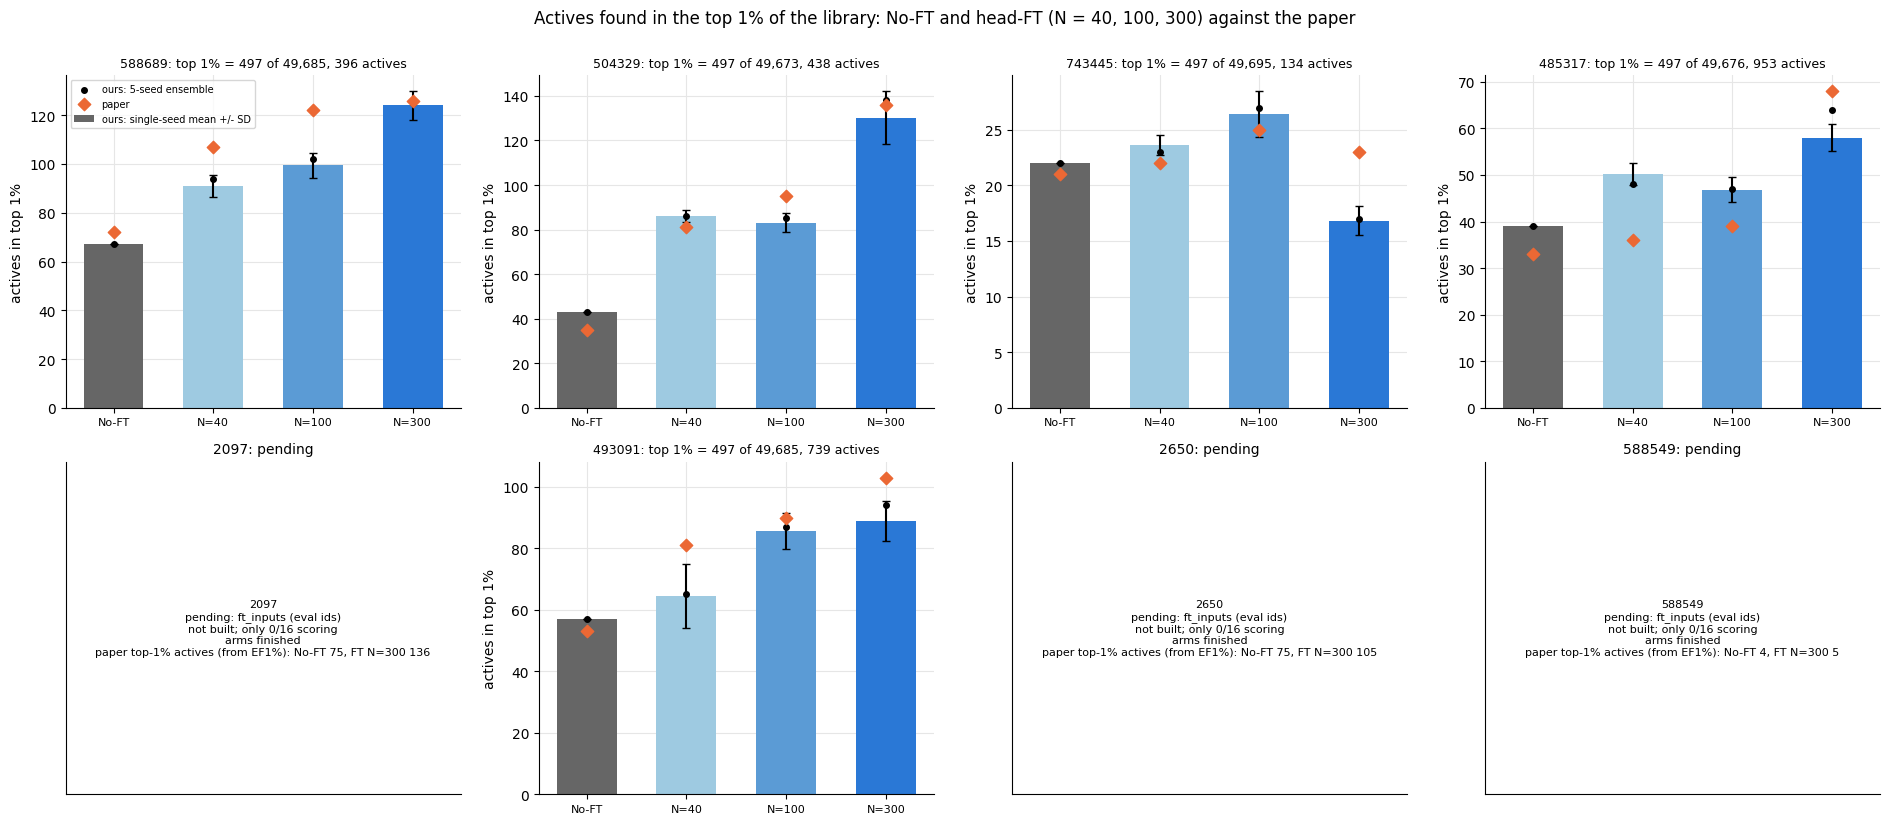

In [3]:
fig, AX = grid(); arms = list(ACOL)
for t, ax in AX.items():
    if t not in D:
        placeholder(ax, t, f"\npaper top-1% actives (from EF1%): No-FT {paper_tp(t):.0f}, FT N=300 {paper_tp(t, 300):.0f}")
        ax.set_title(f"{SHORT[t]}: pending", fontsize=10); continue
    d = D[t]; k = kof(0.01, d["N"])
    for i, a in enumerate(arms):
        tps = [conf_k(s, d["y"], k)["TP"] for s in d["per"][a]]; e = conf_k(d["ens"][a], d["y"], k)["TP"]
        ax.bar(i, np.mean(tps), color=ACOL[a], width=0.6, yerr=(np.std(tps, ddof=1) if len(tps) > 1 else 0.0), capsize=3, ecolor=BLK, label="ours: single-seed mean +/- SD" if i == 0 else None)
        ax.scatter(i, e, color=BLK, s=16, zorder=4, label="ours: 5-seed ensemble" if i == 0 else None)
        pt = paper_tp(t, None if a == "No-FT" else int(a.split("=")[1])); ax.scatter(i, pt, marker="D", color=THEIR, s=40, zorder=5, label="paper" if i == 0 else None)
    ax.set_xticks(range(4)); ax.set_xticklabels(["No-FT", "N=40", "N=100", "N=300"], fontsize=8); ax.set_ylabel("actives in top 1%"); ax.set_title(f"{SHORT[t]}: top 1% = {k} of {d['N']:,}, {d['P']} actives", fontsize=9)
list(AX.values())[0].legend(fontsize=7, loc="upper left")
fig.suptitle("Actives found in the top 1% of the library: No-FT and head-FT (N = 40, 100, 300) against the paper", y=1.0); plt.tight_layout(); plt.show()

### Fixed threshold: p > 0.5
The default decision rule. Fine-tuning shifts probabilities down, so p > 0.5 flags a different number of compounds under each model; counts are therefore not at a matched budget. Ensemble = 5-seed mean probability; single-seed columns give mean +/- SD.

In [4]:
rows = []
for t, d in D.items():
    for arm in d["ens"]:
        c = conf_thr(d["ens"][arm], d["y"]); cs = [conf_thr(s, d["y"]) for s in d["per"][arm]]
        rows.append(dict(target=SHORT[t], arm=arm, flagged=c["flagged"], TP=c["TP"], FP=c["FP"], FN=c["FN"], sens=c["sens"], spec=c["spec"], prec=c["prec"],
                         flagged_seed=msd([x["flagged"] for x in cs]), TP_seed=msd([x["TP"] for x in cs]), FP_seed=msd([x["FP"] for x in cs])))
T1b = pd.DataFrame(rows)
for t in D: print(f"target {SHORT[t]}"); display(T1b[T1b.target == SHORT[t]].set_index("arm").drop(columns="target").round(4))
for t in PEND: print(f"{SHORT[t]}: {PEND[t]}")

target 588689


,flagged,TP,FP,FN,sens,spec,prec,flagged_seed,TP_seed,FP_seed
arm,,,,,,,,,,
No-FT,2062,190,1872,206,0.4798,0.9620,0.0921,2062.0,190.0,1872.0
FT N=40,421,80,341,316,0.2020,0.9931,0.1900,446.4 +/- 205.5,81.4 +/- 28.2,365.0 +/- 177.6
FT N=100,171,48,123,348,0.1212,0.9975,0.2807,184.0 +/- 77.9,48.2 +/- 15.7,135.8 +/- 62.5
FT N=300,200,75,125,321,0.1894,0.9975,0.3750,214.2 +/- 56.3,75.4 +/- 15.9,138.8 +/- 40.5


target 504329


,flagged,TP,FP,FN,sens,spec,prec,flagged_seed,TP_seed,FP_seed
arm,,,,,,,,,,
No-FT,4385,211,4174,227,0.4817,0.9152,0.0481,4385.0,211.0,4174.0
FT N=40,16,10,6,428,0.0228,0.9999,0.6250,16.4 +/- 3.2,10.0 +/- 0.7,6.4 +/- 2.6
FT N=100,92,27,65,411,0.0616,0.9987,0.2935,99.2 +/- 48.2,28.6 +/- 5.8,70.6 +/- 42.6
FT N=300,228,91,137,347,0.2078,0.9972,0.3991,343.2 +/- 231.8,102.6 +/- 37.2,240.6 +/- 195.6


target 743445


...

target 485317


,flagged,TP,FP,FN,sens,spec,prec,flagged_seed,TP_seed,FP_seed
arm,,,,,,,,,,
No-FT,2642,133,2509,820,0.1396,0.9485,0.0503,2642.0,133.0,2509.0
FT N=40,0,0,0,953,0.0000,1.0000,0.0000,0.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0
FT N=100,7,0,7,953,0.0000,0.9999,0.0000,9.2 +/- 5.8,0.2 +/- 0.4,9.0 +/- 5.3
FT N=300,8,3,5,950,0.0031,0.9999,0.3750,9.8 +/- 9.0,3.0 +/- 2.5,6.8 +/- 6.6


target 493091


,flagged,TP,FP,FN,sens,spec,prec,flagged_seed,TP_seed,FP_seed
arm,,,,,,,,,,
No-FT,3603,247,3356,492,0.3342,0.9314,0.0686,3603.0,247.0,3356.0
FT N=40,141,26,115,713,0.0352,0.9977,0.1844,177.2 +/- 114.8,30.0 +/- 16.8,147.2 +/- 98.4
FT N=100,79,17,62,722,0.0230,0.9987,0.2152,88.6 +/- 32.7,19.8 +/- 6.3,68.8 +/- 26.5
FT N=300,89,29,60,710,0.0392,0.9988,0.3258,157.6 +/- 108.9,41.2 +/- 20.7,116.4 +/- 88.7


2097: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
2650: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
588549: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished


### Specificity-sensitivity trade-off curves (ROC zoomed on the low false-positive region, log x)
x: false-positive rate = 1 - specificity (log scale); y: sensitivity. Grey: No-FT. Blue thick: head-FT N=300 5-seed ensemble; thin blue: the five single seeds. The region left of x = 0.01 is the part that matters for a screen.

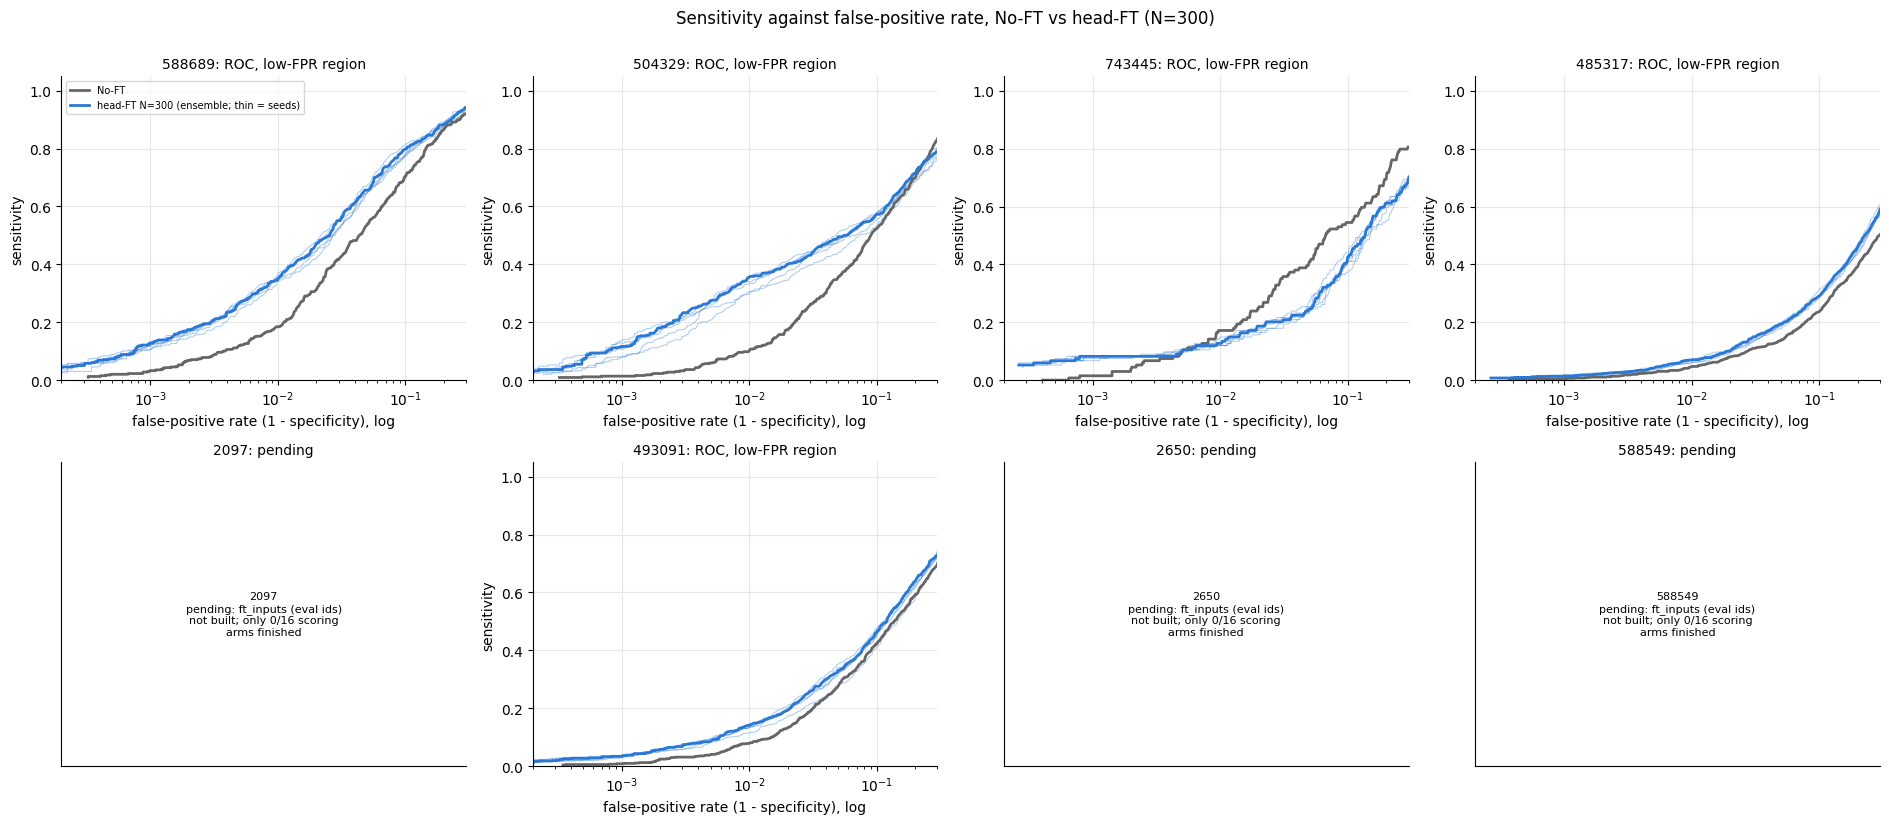

In [5]:
def curve(score, y):
    o = order(score); cs = np.cumsum(y[o]); k = np.arange(1, len(y) + 1); P = y.sum(); neg = len(y) - P
    return (k - cs) / neg, cs / P, cs / k
fig, AX = grid()
for t, ax in AX.items():
    if t not in D: placeholder(ax, t); ax.set_title(f"{SHORT[t]}: pending", fontsize=10); continue
    d = D[t]; ks = np.unique(np.geomspace(20, d["N"], 600).astype(int)) - 1
    for s in d["per"]["FT N=300"]: f, r, _ = curve(s, d["y"]); ax.plot(f[ks], r[ks], color=OUR, lw=0.7, alpha=0.4)
    for a, lw in [("No-FT", 2), ("FT N=300", 2)]:
        f, r, _ = curve(d["ens"][a], d["y"]); ax.plot(f[ks], r[ks], color=ACOL[a], lw=lw, label=a if a == "No-FT" else "head-FT N=300 (ensemble; thin = seeds)")
    ax.set_xscale("log"); ax.set_xlim(2e-4, 0.3); ax.set_ylim(0, None); ax.set_xlabel("false-positive rate (1 - specificity), log"); ax.set_ylabel("sensitivity"); ax.set_title(f"{SHORT[t]}: ROC, low-FPR region", fontsize=10)
list(AX.values())[0].legend(fontsize=7, loc="upper left"); fig.suptitle("Sensitivity against false-positive rate, No-FT vs head-FT (N=300)", y=1.0); plt.tight_layout(); plt.show()

### Precision against sensitivity (log x)
x: sensitivity (log); y: precision (share of flagged compounds that are active). Dashed: active rate = a random ranking.

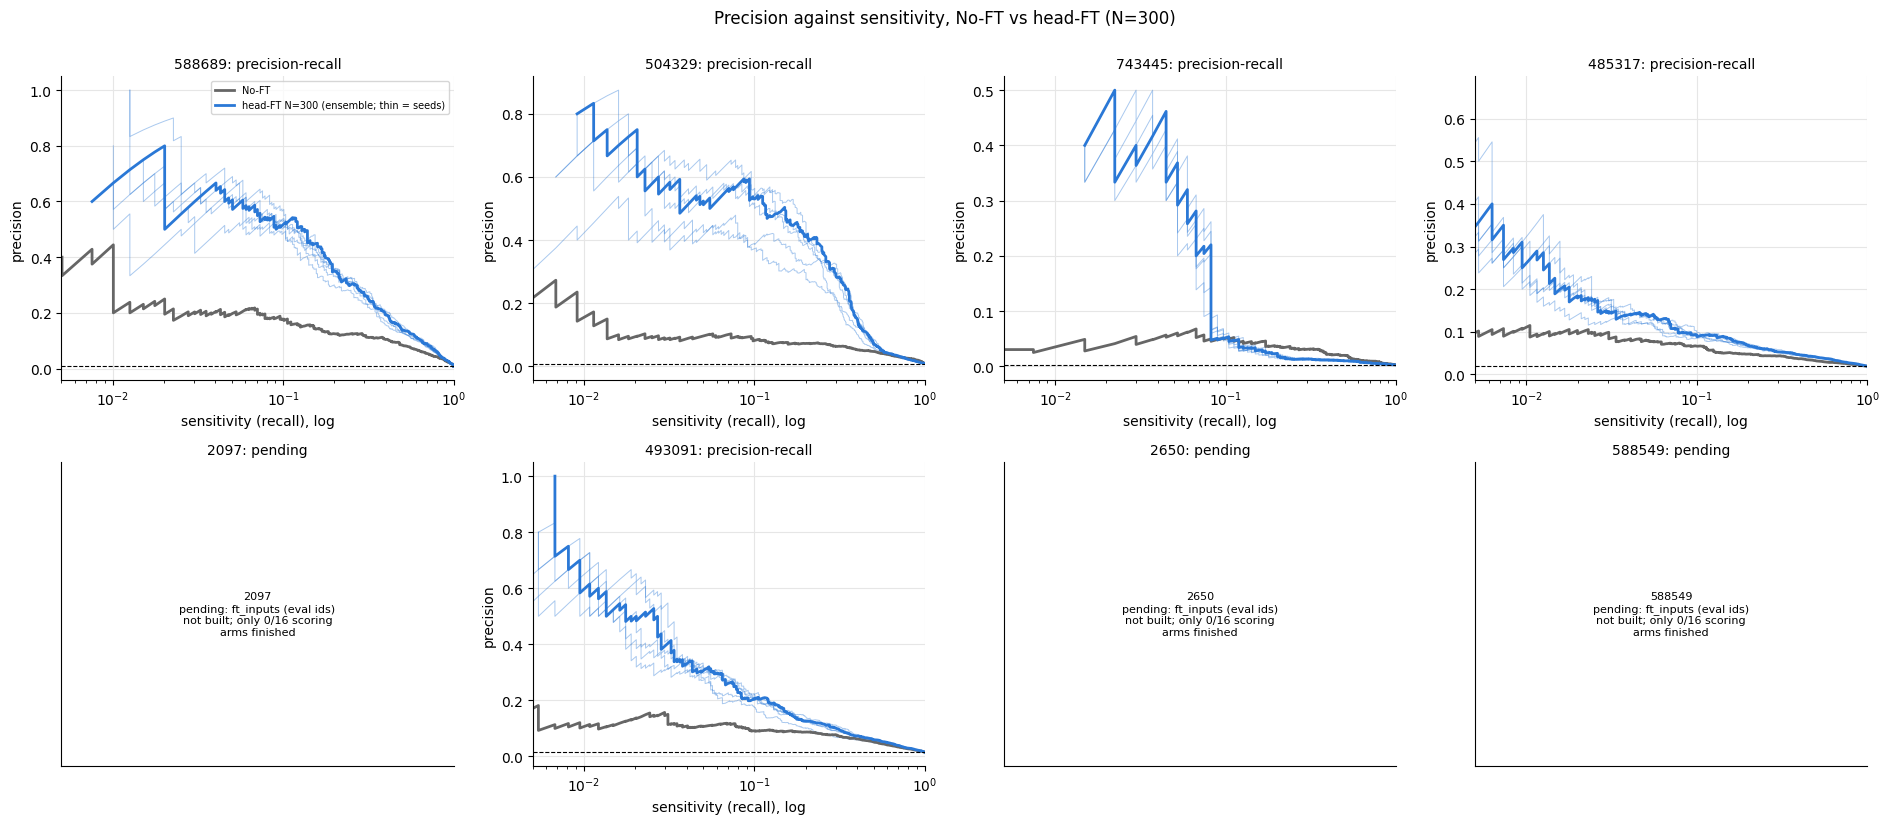

In [6]:
fig, AX = grid()
for t, ax in AX.items():
    if t not in D: placeholder(ax, t); ax.set_title(f"{SHORT[t]}: pending", fontsize=10); continue
    d = D[t]; ks = np.unique(np.geomspace(5, d["N"], 600).astype(int)) - 1
    for s in d["per"]["FT N=300"]: f, r, p = curve(s, d["y"]); ax.plot(r[ks], p[ks], color=OUR, lw=0.7, alpha=0.4)
    for a in ["No-FT", "FT N=300"]:
        f, r, p = curve(d["ens"][a], d["y"]); ax.plot(r[ks], p[ks], color=ACOL[a], lw=2, label=a if a == "No-FT" else "head-FT N=300 (ensemble; thin = seeds)")
    ax.axhline(d["y"].mean(), color=BLK, ls="--", lw=0.8); ax.set_xscale("log"); ax.set_xlim(0.005, 1); ax.set_xlabel("sensitivity (recall), log"); ax.set_ylabel("precision"); ax.set_title(f"{SHORT[t]}: precision-recall", fontsize=10)
list(AX.values())[0].legend(fontsize=7, loc="upper right"); fig.suptitle("Precision against sensitivity, No-FT vs head-FT (N=300)", y=1.0); plt.tight_layout(); plt.show()

## 2. Does fine-tuning discard true negatives better but miss more actives?

Two things can be true at once, so both are reported per target and never merged.
- Matched number flagged (top 1%): FP = k - TP, so finding more actives and having fewer false positives are the same statement. The interval is the paired bootstrap of the difference (head-FT N=300 ensemble minus No-FT).
- Default threshold p > 0.5: the number flagged differs between models, so a real trade-off can appear (fewer false positives and more missed actives, or the opposite).
- Matched sensitivity: how many false positives must be accepted to reach the same number of actives (sensitivity 25%, 50%, and No-FT's own top-1% sensitivity). This is the specificity view at equal recall.

In [7]:
R2 = {}; LV = (0.25, 0.5)
for t, d in D.items():
    try:
        y, a, b = d["y"], d["ens"]["No-FT"], d["ens"]["FT N=300"]; k = kof(0.01, d["N"]); ca, cb = conf_k(a, y, k), conf_k(b, y, k)
        bt = boot_diff(a, b, y, frac=0.01, sens_levels=LV, B=300, seed=1)
        tps = [conf_k(s, y, k)["TP"] for s in d["per"]["FT N=300"]]
        r = dict(k=k, TP_a=ca["TP"], TP_b=cb["TP"], dTP=cb["TP"] - ca["TP"], dTP_ci=ci(bt["dTP"]), seed_TP=tps, FP_a=ca["FP"], FP_b=cb["FP"], spec_a=ca["spec"], spec_b=cb["spec"])
        ta, tb = conf_thr(a, y), conf_thr(b, y); r.update(thr_a=ta, thr_b=tb, thr_seed=[conf_thr(s, y) for s in d["per"]["FT N=300"]])
        ms = []
        for lab, tpt, bk in [(f"sensitivity {int(100*l)}%", int(np.ceil(l * d["P"])), f"dFP@{l}") for l in LV] + [("No-FT top-1% sensitivity", ca["TP"], None)]:
            fa, ka = fp_at_sens(a, y, tpt); fb, kb = fp_at_sens(b, y, tpt)
            ms.append(dict(level=lab, TP=tpt, FP_noft=fa, FP_ft=fb, dFP=fb - fa, dFP_ci=ci(bt[bk]) if bk else (np.nan, np.nan), spec_noft=1 - fa / (d["N"] - d["P"]), spec_ft=1 - fb / (d["N"] - d["P"])))
        r["matched"] = pd.DataFrame(ms); R2[t] = r
    except Exception as e:
        print(f"{SHORT[t]}: section 2 failed ({type(e).__name__}: {e}); skipped")
def verdict(ta, tb):
    fewer_fp, more_fn = tb["FP"] < ta["FP"], tb["FN"] > ta["FN"]
    if fewer_fp and more_fn: return "trade-off: fewer false positives but more missed actives"
    if fewer_fp and not more_fn: return "better on both: fewer false positives and no more missed actives"
    if (not fewer_fp) and more_fn: return "worse on both: more false positives and more missed actives"
    return "more false positives but fewer missed actives (head-FT is the more permissive rule)"
for t, r in R2.items():
    print(f"=== target {SHORT[t]} (k = {r['k']}) ===")
    print(f"matched top 1%: actives No-FT {r['TP_a']} vs head-FT {r['TP_b']} (difference {r['dTP']:+d}, 95% bootstrap CI [{r['dTP_ci'][0]:+.0f}, {r['dTP_ci'][1]:+.0f}]; seed range {min(r['seed_TP'])}-{max(r['seed_TP'])}); "
          f"false positives {r['FP_a']} vs {r['FP_b']}; specificity {100*r['spec_a']:.2f}% vs {100*r['spec_b']:.2f}%")
    ta, tb = r["thr_a"], r["thr_b"]; sf = r["thr_seed"]
    print(f"p > 0.5: No-FT flags {ta['flagged']}, finds {ta['TP']}, misses {ta['FN']}, FP {ta['FP']}, specificity {100*ta['spec']:.2f}% | head-FT ensemble flags {tb['flagged']}, finds {tb['TP']}, misses {tb['FN']}, FP {tb['FP']}, specificity {100*tb['spec']:.2f}% "
          f"(single seeds: flagged {msd([x['flagged'] for x in sf])}, found {msd([x['TP'] for x in sf])}, FP {msd([x['FP'] for x in sf])})  -> {verdict(ta, tb)}")
    m = r["matched"].copy(); m["dFP 95% CI"] = [("" if np.isnan(c[0]) else f"[{c[0]:+.0f}, {c[1]:+.0f}]") for c in m.dFP_ci]; display(m.drop(columns="dFP_ci").set_index("level").round(4))
for t in PEND: print(f"{SHORT[t]}: {PEND[t]}")

=== target 588689 (k = 497) ===
matched top 1%: actives No-FT 67 vs head-FT 125 (difference +58, 95% bootstrap CI [+40, +76]; seed range 116-131); false positives 430 vs 372; specificity 99.13% vs 99.25%
p > 0.5: No-FT flags 2062, finds 190, misses 206, FP 1872, specificity 96.20% | head-FT ensemble flags 200, finds 75, misses 321, FP 125, specificity 99.75% (single seeds: flagged 214.2 +/- 56.3, found 75.4 +/- 15.9, FP 138.8 +/- 40.5)  -> trade-off: fewer false positives but more missed actives


,TP,FP_noft,FP_ft,dFP,spec_noft,spec_ft,dFP 95% CI
level,,,,,,,
sensitivity 25%,99,692,229,-463,0.9860,0.9954,"[-618, -356]"
sensitivity 50%,198,2144,1249,-895,0.9565,0.9747,"[-1411, -449]"
No-FT top-1% sensitivity,67,411,89,-322,0.9917,0.9982,


=== target 504329 (k = 497) ===
matched top 1%: actives No-FT 43 vs head-FT 138 (difference +95, 95% bootstrap CI [+78, +115]; seed range 115-142); false positives 454 vs 359; specificity 99.08% vs 99.27%
p > 0.5: No-FT flags 4385, finds 211, misses 227, FP 4174, specificity 91.52% | head-FT ensemble flags 228, finds 91, misses 347, FP 137, specificity 99.72% (single seeds: flagged 343.2 +/- 231.8, found 102.6 +/- 37.2, FP 240.6 +/- 195.6)  -> trade-off: fewer false positives but more missed actives


,TP,FP_noft,FP_ft,dFP,spec_noft,spec_ft,dFP 95% CI
level,,,,,,,
sensitivity 25%,110,1425,188,-1237,0.9711,0.9962,"[-1645, -995]"
sensitivity 50%,219,4403,2721,-1682,0.9106,0.9447,"[-2756, -661]"
No-FT top-1% sensitivity,43,444,37,-407,0.9910,0.9992,


=== target 743445 (k = 497) ===
matched top 1%: actives No-FT 22 vs head-FT 17 (difference -5, 95% bootstrap CI [-16, +5]; seed range 16-19); false positives 475 vs 480; specificity 99.04% vs 99.03%
p > 0.5: No-FT flags 4838, finds 73, misses 61, FP 4765, specificity 90.39% | head-FT ensemble flags 24, finds 7, misses 127, FP 17, specificity 99.97% (single seeds: flagged 28.0 +/- 8.8, found 7.8 +/- 1.6, FP 20.2 +/- 7.3)  -> trade-off: fewer false positives but more missed actives


...

=== target 485317 (k = 497) ===
matched top 1%: actives No-FT 39 vs head-FT 64 (difference +25, 95% bootstrap CI [+8, +38]; seed range 54-61); false positives 458 vs 433; specificity 99.06% vs 99.11%
p > 0.5: No-FT flags 2642, finds 133, misses 820, FP 2509, specificity 94.85% | head-FT ensemble flags 8, finds 3, misses 950, FP 5, specificity 99.99% (single seeds: flagged 9.8 +/- 9.0, found 3.0 +/- 2.5, FP 6.8 +/- 6.6)  -> trade-off: fewer false positives but more missed actives


,TP,FP_noft,FP_ft,dFP,spec_noft,spec_ft,dFP 95% CI
level,,,,,,,
sensitivity 25%,239,5143,3786,-1357,0.8944,0.9223,"[-2154, -742]"
sensitivity 50%,477,14480,11063,-3417,0.7028,0.7729,"[-4857, -1680]"
No-FT top-1% sensitivity,39,425,233,-192,0.9913,0.9952,


=== target 493091 (k = 497) ===
matched top 1%: actives No-FT 57 vs head-FT 94 (difference +37, 95% bootstrap CI [+20, +55]; seed range 78-94); false positives 440 vs 403; specificity 99.10% vs 99.18%
p > 0.5: No-FT flags 3603, finds 247, misses 492, FP 3356, specificity 93.14% | head-FT ensemble flags 89, finds 29, misses 710, FP 60, specificity 99.88% (single seeds: flagged 157.6 +/- 108.9, found 41.2 +/- 20.7, FP 116.4 +/- 88.7)  -> trade-off: fewer false positives but more missed actives


,TP,FP_noft,FP_ft,dFP,spec_noft,spec_ft,dFP 95% CI
level,,,,,,,
sensitivity 25%,185,2110,1395,-715,0.9569,0.9715,"[-1020, -416]"
sensitivity 50%,370,6681,5818,-863,0.8635,0.8811,"[-1968, -146]"
No-FT top-1% sensitivity,57,427,169,-258,0.9913,0.9965,


2097: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
2650: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
588549: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished


### Operating points of the two models
Each panel places No-FT and head-FT (N=300 ensemble) in the plane of false positives (log x) against actives found, at the matched top-1% cutoff (circles) and at p > 0.5 (squares). Up and to the left is better.

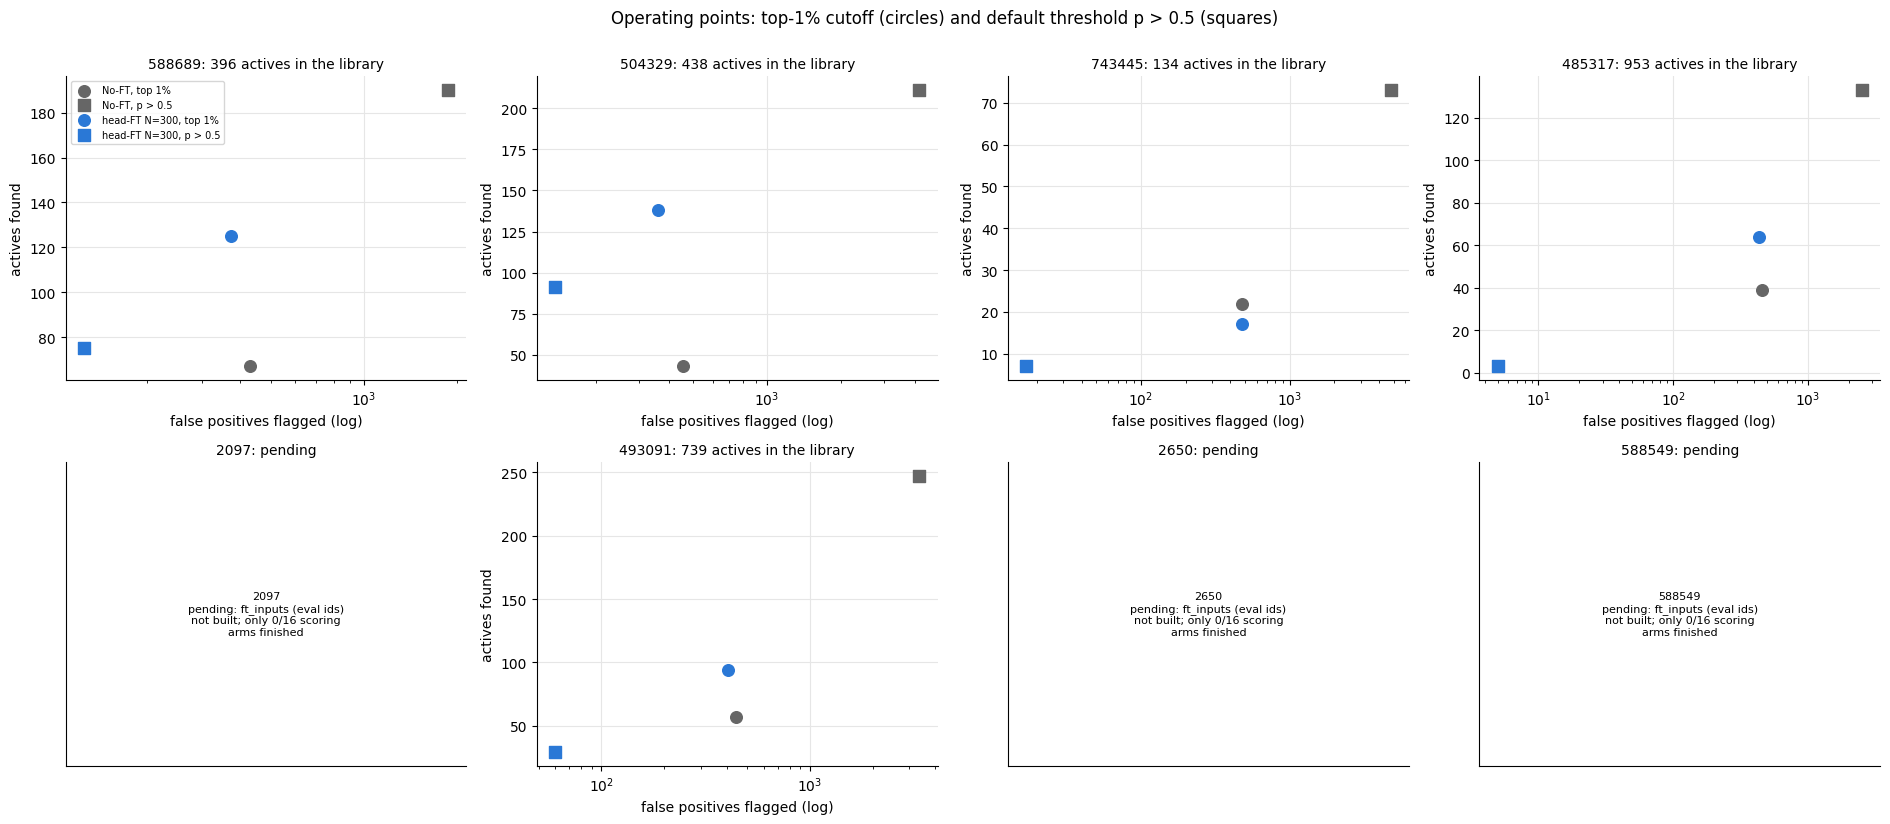

In [8]:
fig, AX = grid()
for t, ax in AX.items():
    if t not in R2: placeholder(ax, t); ax.set_title(f"{SHORT[t]}: pending", fontsize=10); continue
    r = R2[t]
    for nm, c, ta in [("No-FT", GREY, r["thr_a"]), ("head-FT N=300", OUR, r["thr_b"])]:
        tp, fp = (r["TP_a"], r["FP_a"]) if nm == "No-FT" else (r["TP_b"], r["FP_b"])
        ax.scatter(max(fp, 1), tp, color=c, s=70, marker="o", label=f"{nm}, top 1%"); ax.scatter(max(ta["FP"], 1), ta["TP"], color=c, s=70, marker="s", label=f"{nm}, p > 0.5")
    ax.set_xscale("log"); ax.set_xlabel("false positives flagged (log)"); ax.set_ylabel("actives found"); ax.set_title(f"{SHORT[t]}: {D[t]['P']} actives in the library", fontsize=10)
list(AX.values())[0].legend(fontsize=7); fig.suptitle("Operating points: top-1% cutoff (circles) and default threshold p > 0.5 (squares)", y=1.0); plt.tight_layout(); plt.show()

## 3. Re-ranking: which compounds move, which actives are rescued or lost

Each compound has a rank under No-FT and under head-FT (N=300, 5-seed ensemble); 1 = best. With the top-1% cut: promoted actives are actives in head-FT's top 1% but not No-FT's, lost actives the reverse, kept actives are in both; demoted false positives are inactives that No-FT flagged and head-FT does not, new false positives the reverse. The shift is log2(No-FT rank / head-FT rank), positive = moved up.

In [9]:
RR = {}
for t, d in D.items():
    try:
        S = d["S"].copy(); k = kof(0.01, d["N"]); S["rank_noft"] = S.noft_p.rank(ascending=False, method="first").astype(int)
        S["ft"] = d["ens"]["FT N=300"]; S["rank_ft"] = S.ft.rank(ascending=False, method="first").astype(int)
        S["in_noft"], S["in_ft"] = S.rank_noft <= k, S.rank_ft <= k; S["rshift"] = np.log2(S.rank_noft / S.rank_ft); a1 = S.label == 1; a0 = S.label == 0
        G = {"promoted actives": a1 & S.in_ft & ~S.in_noft, "lost actives": a1 & S.in_noft & ~S.in_ft, "kept actives": a1 & S.in_ft & S.in_noft,
             "demoted false positives": a0 & S.in_noft & ~S.in_ft, "new false positives": a0 & S.in_ft & ~S.in_noft, "kept false positives": a0 & S.in_ft & S.in_noft}
        pr, lo = [], []                                 # per seed: promoted / lost actives (seed ranking vs No-FT)
        for s in d["per"]["FT N=300"]:
            ins = pd.Series(s).rank(ascending=False, method="first").values <= k; pr.append(int((a1.values & ins & ~S.in_noft.values).sum())); lo.append(int((a1.values & ~ins & S.in_noft.values).sum()))
        RR[t] = dict(S=S, G=G, k=k, seed_prom=pr, seed_lost=lo)
    except Exception as e:
        print(f"{SHORT[t]}: section 3 failed ({type(e).__name__}: {e}); skipped")
rows = [dict(target=SHORT[t], k=r["k"], **{g: int(m.sum()) for g, m in r["G"].items()}, promoted_seed=msd(r["seed_prom"]), lost_seed=msd(r["seed_lost"]),
             changed_status=int(sum(m.sum() for g, m in r["G"].items() if g in ("promoted actives", "lost actives", "demoted false positives", "new false positives")))) for t, r in RR.items()]
T3 = pd.DataFrame(rows).set_index("target"); display(T3)
for t in PEND: print(f"{SHORT[t]}: {PEND[t]}")

,k,promoted actives,lost actives,kept actives,demoted false positives,new false positives,kept false positives,promoted_seed,lost_seed,changed_status
target,,,,,,,,,,
588689,497,76,18,49,334,276,96,76.8 +/- 5.3,19.8 +/- 1.5,704
504329,497,105,10,33,366,271,88,97.8 +/- 11.3,10.6 +/- 1.1,752
743445,497,10,15,7,387,392,88,10.0 +/- 0.7,15.2 +/- 0.8,804
485317,497,46,21,18,357,332,101,41.2 +/- 4.4,22.2 +/- 2.6,756
493091,497,64,27,30,331,294,109,60.4 +/- 6.9,28.4 +/- 1.7,716


2097: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
2650: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
588549: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished


### Every compound, before and after
Rank under No-FT (x) against rank under head-FT (y), log scales, 1 = best at the top-right. Dashed: top 1%. Points above the diagonal moved up.

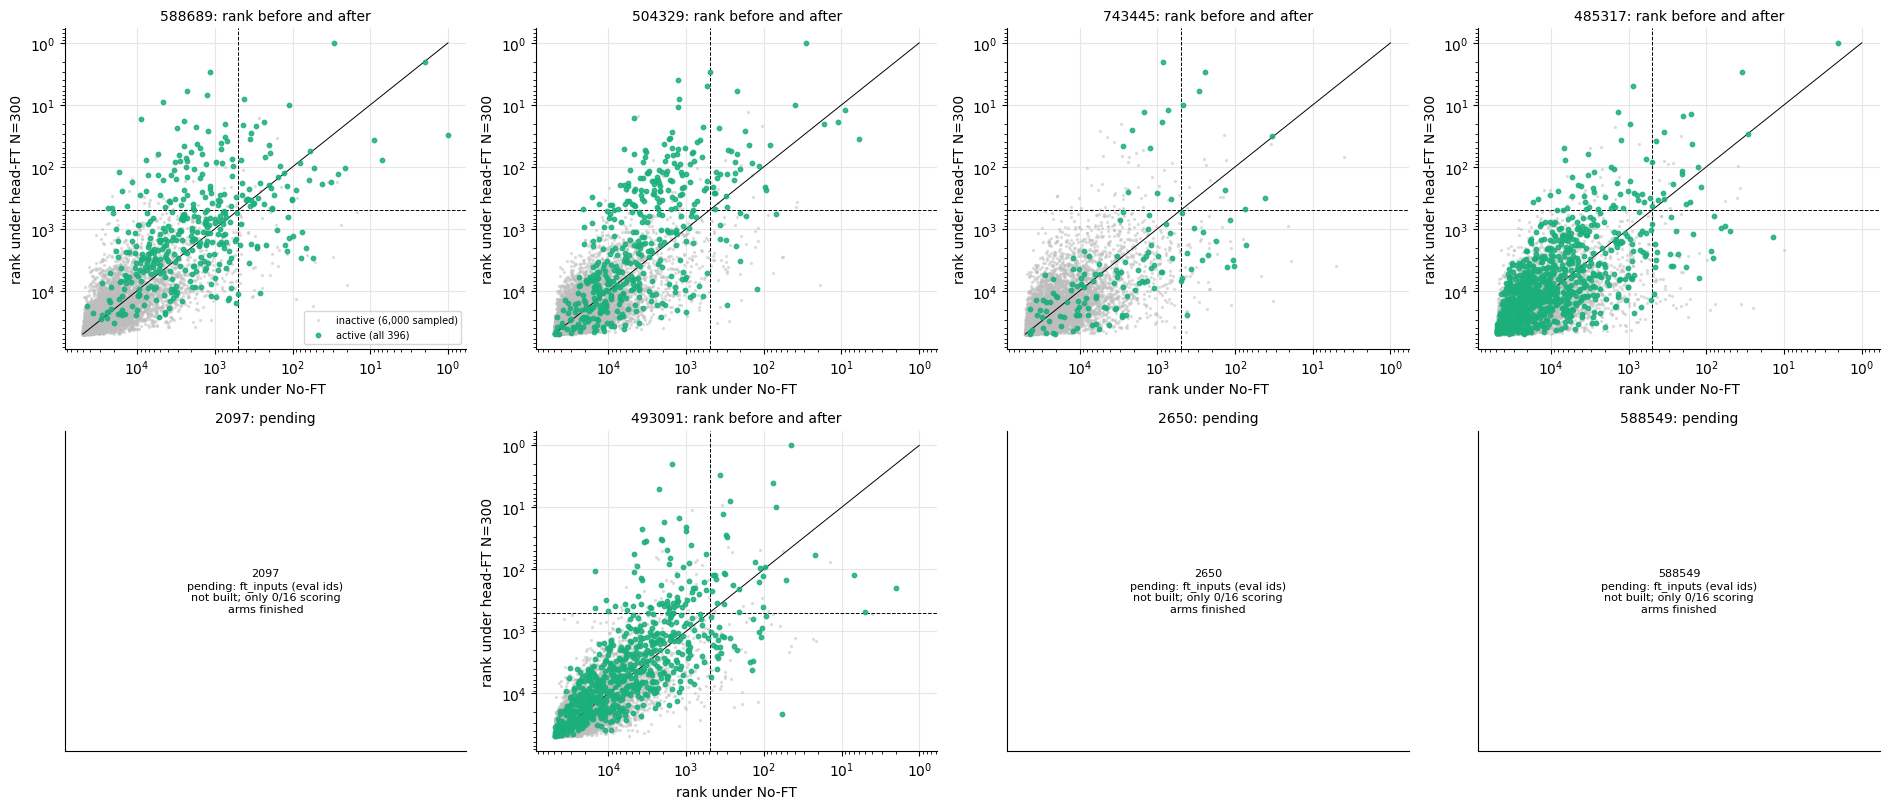

In [10]:
fig, AX = grid()
for t, ax in AX.items():
    if t not in RR: placeholder(ax, t); ax.set_title(f"{SHORT[t]}: pending", fontsize=10); continue
    S, k, N = RR[t]["S"], RR[t]["k"], len(RR[t]["S"]); ina = S[S.label == 0].sample(n=min(6000, int((S.label == 0).sum())), random_state=0)
    ax.scatter(ina.rank_noft, ina.rank_ft, s=2, color="#bdbdbd", alpha=0.4, rasterized=True, label="inactive (6,000 sampled)")
    a = S[S.label == 1]; ax.scatter(a.rank_noft, a.rank_ft, s=10, color="#1baf7a", alpha=0.85, zorder=3, label=f"active (all {len(a)})")
    ax.plot([1, N], [1, N], color=BLK, lw=0.7); ax.axvline(k, ls="--", color=BLK, lw=0.7); ax.axhline(k, ls="--", color=BLK, lw=0.7)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.invert_xaxis(); ax.invert_yaxis(); ax.set_xlabel("rank under No-FT"); ax.set_ylabel("rank under head-FT N=300"); ax.set_title(f"{SHORT[t]}: rank before and after", fontsize=10)
list(AX.values())[0].legend(fontsize=7, loc="lower right"); plt.tight_layout(); plt.show()

### How far do compounds move?
Distribution of the rank shift for actives and inactives.

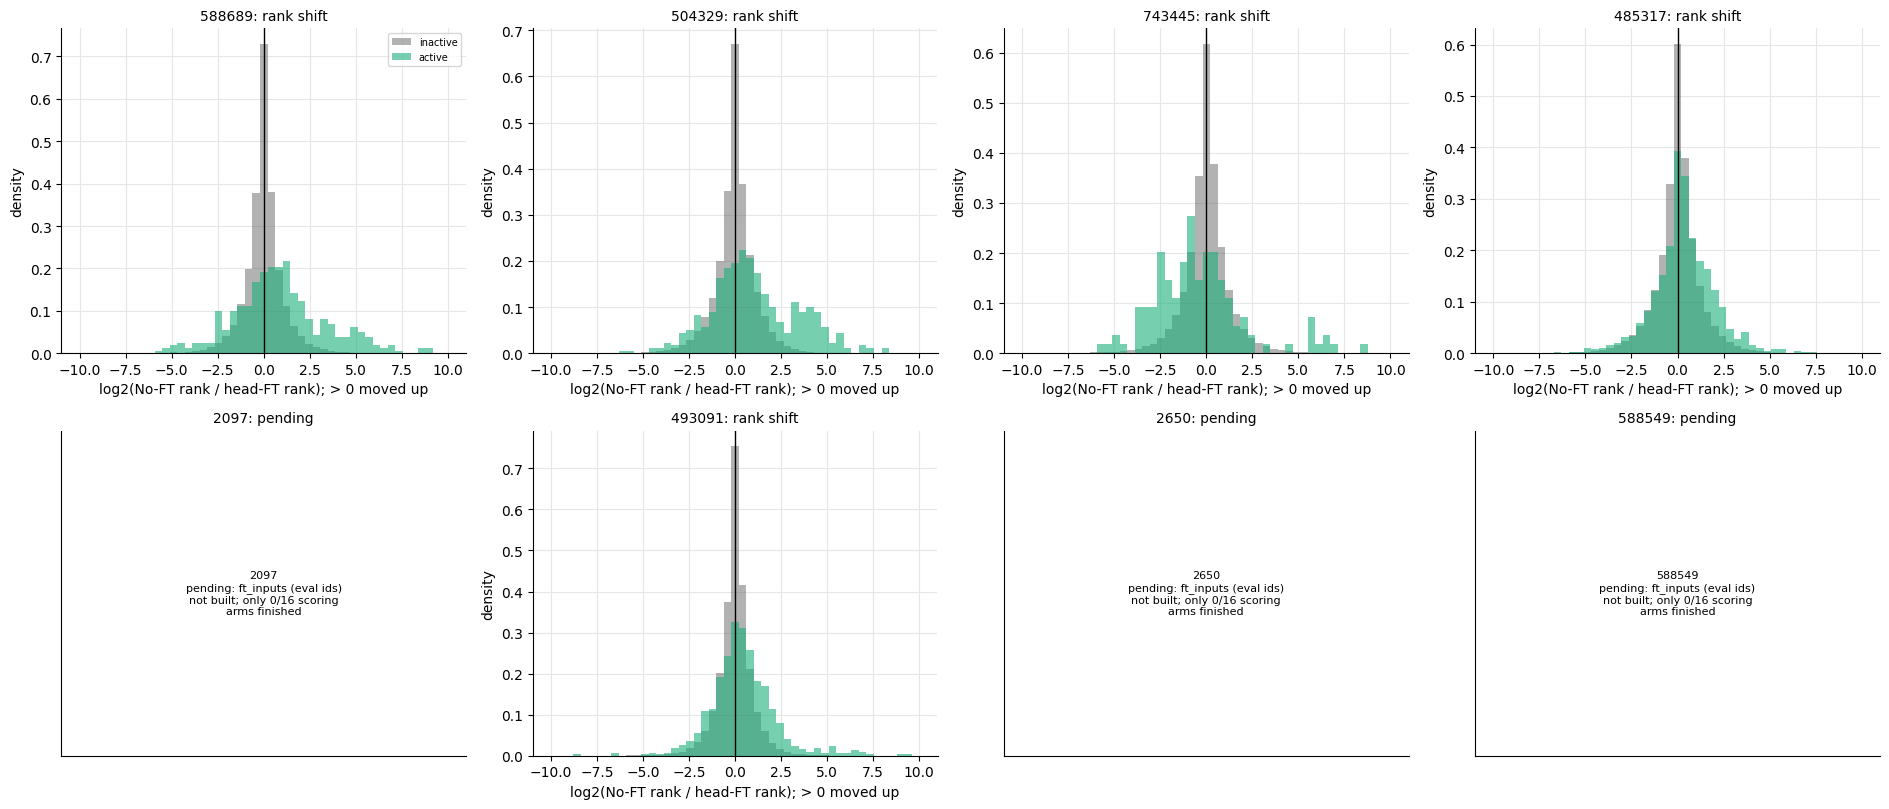

n  median_shift  factor  pct_up  pct_up_4x  pct_down_4x
target group                                                                
588689 active      396          0.67    1.59   64.14      26.77        11.36
       inactive  49289         -0.00    1.00   49.84       3.32         3.42
504329 active      438          0.75    1.68   65.98      29.91         7.99
       inactive  49235          0.01    1.01   50.82       3.64         4.18
743445 active      134         -0.73    0.60   36.57      11.19        26.87
       inactive  49561          0.01    1.01   50.89       4.84         4.86
485317 active      953          0.27    1.20   61.80      13.85         6.72
       inactive  48723          0.03    1.02   52.07       4.99         5.59
493091 active      739          0.30    1.23   60.35      12.58         5.55
       inactive  48946          0.01    1.01   51.09       2.35         2.69

In [11]:
fig, AX = grid(); b = np.linspace(-10, 10, 50); SH = []
for t, ax in AX.items():
    if t not in RR: placeholder(ax, t); ax.set_title(f"{SHORT[t]}: pending", fontsize=10); continue
    S = RR[t]["S"]; ax.hist(S[S.label == 0].rshift.clip(-10, 10), bins=b, density=True, alpha=0.5, color=GREY, label="inactive"); ax.hist(S[S.label == 1].rshift.clip(-10, 10), bins=b, density=True, alpha=0.6, color="#1baf7a", label="active")
    ax.axvline(0, color=BLK, lw=1); ax.set_xlabel("log2(No-FT rank / head-FT rank); > 0 moved up"); ax.set_ylabel("density"); ax.set_title(f"{SHORT[t]}: rank shift", fontsize=10)
    for lab, nm in [(1, "active"), (0, "inactive")]:
        v = S[S.label == lab].rshift; SH.append(dict(target=SHORT[t], group=nm, n=len(v), median_shift=v.median(), factor=2 ** v.median(), pct_up=100 * (v > 0).mean(), pct_up_4x=100 * (v > 2).mean(), pct_down_4x=100 * (v < -2).mean()))
list(AX.values())[0].legend(fontsize=7); plt.tight_layout(); plt.show(); TSH = pd.DataFrame(SH).set_index(["target", "group"]); display(TSH.round(2))

### What do the rescued actives look like?
Two descriptors, both computed without the fine-tuned model.
1. Percentile under the dataset's own other scores (Boltz-2 score, Boltzina, gnina, vina). Each score is oriented so that a higher percentile is 'better' (the orientation is set by which direction gives AUROC above 0.5 over the whole library, so it is data-derived; AUROC shown). A rescued active with a high percentile is one that other methods also liked; a low percentile would mean fine-tuning found something those scores miss. gnina and vina are available only for part of the library.
2. Highest ECFP4 Tanimoto (2048 bits, radius 2) to any of the 300-compound training set's actives. Training compounds are not in the evaluation set, but their analogs can be.

In [12]:
from scipy.stats import mannwhitneyu
DS = ["score_boltz2", "score_boltzina", "score_gnina", "score_vina"]; rows = []; SIM = {}
for t, r in RR.items():
    S, G = r["S"], r["G"]
    for c in DS:
        try:
            o = oriented_percentiles(S, c)
            if o is None: continue
            pc, auc = o; v = lambda m: pc[m].dropna()
            pa, la, al = v(G["promoted actives"]), v(G["lost actives"]), v(S.label == 1)
            rows.append(dict(target=SHORT[t], score=c, coverage=f"{100*S[c].notna().mean():.0f}%", AUROC=auc, n_promoted=len(pa), med_promoted=pa.median(), n_lost=len(la), med_lost=la.median(), med_all_actives=al.median(),
                             p_prom_vs_all=mannwhitneyu(pa, al).pvalue if len(pa) > 2 else np.nan))
        except Exception as e:
            print(f"{SHORT[t]} {c}: {type(e).__name__}: {e}")
TD = pd.DataFrame(rows)
if len(TD): display(TD.set_index(["target", "score"]).round(3)); print(f"{len(TD)} Mann-Whitney tests (promoted actives vs all held-out actives); Bonferroni threshold for 0.05: {0.05/len(TD):.4f}. Tests within a target are not independent and targets with few promoted actives have little power.")
for t in PEND: print(f"{SHORT[t]}: {PEND[t]}")

coverage  AUROC  n_promoted  med_promoted  n_lost  \
target score                                                              
588689 score_boltz2       100%  0.910          76        96.146      18   
       score_boltzina     100%  0.821          76        85.168      18   
       score_gnina         44%  0.604          30        33.757      13   
       score_vina          44%  0.602          30        58.808      13   
504329 score_boltz2       100%  0.833         105        95.247      10   
       score_boltzina     100%  0.762         105        90.480      10   
       score_gnina         25%  0.473          23        41.780       3   
       score_vina          25%  0.428          23        77.027       3   
743445 score_boltz2       100%  0.835          10        96.608      15   
       score_boltzina     100%  0.761          10        94.758      15   
       score_gnina        100%  0.534          10        27.619      15   
       score_vina         100%  0.438          10        49.671      15   
485317 score_boltz2       100%  0.636          46        94.581      21   
       score_boltzina     100%  0.582          46        81.158      21   
       score_gnina        100%  0.512          46        41.750      21   
       score_vina         100%  0.483          46        65.015      21   
493091 score_boltz2       100%  0.772          64        96.184      27   
       score_boltzina     100%  0.727          64        93.344      27   
       score_gnina        100%  0.483          64        60.982      27   
       score_vina         100%  0.564          64        72.144      27   

                       med_lost  med_all_actives  p_prom_vs_all  
target score                                                     
588689 score_boltz2      99.478           95.269          0.638  
       score_boltzina    97.163           86.682          0.553  
       score_gnina       89.984           68.332          0.005  
       score_vina        80.077           69.552          0.741  
504329 score_boltz2      99.067           89.920          0.000  
       score_boltzina    93.173           83.210          0.000  
       score_gnina       90.608           48.379          0.290  
       score_vina        28.959           61.870          0.041  
743445 score_boltz2      99.418           93.167          0.066  
       score_boltzina    92.045           87.488          0.015  
       score_gnina       59.995           55.783          0.068  
       score_vina        54.435           59.276          0.231  
485317 score_boltz2      99.171           69.713          0.000  
       score_boltzina    97.079           59.183          0.000  
       score_gnina       55.680           51.531          0.075  
       score_vina        55.185           52.797          0.037  
493091 score_boltz2      99.380           85.106          0.000  
       score_boltzina    97.683           78.591          0.000  
       score_gnina       61.704           53.414          0.114  
       score_vina        55.199           58.765          0.032

20 Mann-Whitney tests (promoted actives vs all held-out actives); Bonferroni threshold for 0.05: 0.0025. Tests within a target are not independent and targets with few promoted actives have little power.
2097: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
2650: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
588549: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished


n  median_maxTanimoto  pct_ge_0_5  \
target group                                                          
588689 promoted actives          76                0.47       42.11   
       lost actives              18                0.31       11.11   
       kept actives              49                0.41       38.78   
       all held-out actives     396                0.28       17.93   
       new false positives      276                0.26        6.16   
       demoted false positives  334                0.23        1.80   
       random inactives (500)   500                0.22        0.60   
504329 promoted actives         105                0.32       14.29   
       lost actives              10                0.20        0.00   
       kept actives              33                0.36       33.33   
       all held-out actives     438                0.23        6.85   
       new false positives      271                0.24        2.21   
       demoted false positives  366                0.19        0.55   
       random inactives (500)   500                0.20        0.00   
743445 promoted actives          10                0.34       30.00   
       lost actives              15                0.15        0.00   
       kept actives               7                0.23       42.86   
       all held-out actives     134                0.17        4.48   
       new false positives      392                0.20        2.55   
       demoted false positives  387                0.17        0.00   
       random inactives (500)   500                0.17        0.00   
485317 promoted actives          46                0.26       10.87   
       lost actives              21                0.29        0.00   
       kept actives              18                0.27       16.67   
       all held-out actives     953                0.21        1.36   
       new false positives      332                0.24        0.90   
       demoted false positives  357                0.21        1.68   
       random inactives (500)   500                0.19        0.00   
493091 promoted actives          64                0.32       18.75   
       lost actives              27                0.30       33.33   
       kept actives              30                0.32       16.67   
       all held-out actives     739                0.26        5.41   
       new false positives      294                0.28        3.06   
       demoted false positives  331                0.23        0.91   
       random inactives (500)   500                0.21        0.00   

                                pct_ge_0_6  
target group                                
588689 promoted actives              27.63  
       lost actives                   5.56  
       kept actives                  32.65  
       all held-out actives          11.36  
       new false positives            1.81  
       demoted false positives        0.90  
       random inactives (500)         0.40  
504329 promoted actives               3.81  
       lost actives                   0.00  
       kept actives                  15.15  
       all held-out actives           2.28  
       new false positives            1.11  
       demoted false positives        0.27  
       random inactives (500)         0.00  
743445 promoted actives               0.00  
       lost actives                   0.00  
       kept actives                  14.29  
       all held-out actives           0.75  
       new false positives            0.26  
       demoted false positives        0.00  
       random inactives (500)         0.00  
485317 promoted actives               2.17  
       lost actives                   0.00  
       kept actives                   0.00  
       all held-out actives           0.21  
       new false positives            0.30  
       demoted false positives        0.28  
       random inactives (500)         0.00  
493091 promoted actives              15.62  
       lost

588689: 90 training actives used as reference
504329: 28 training actives used as reference
743445: 10 training actives used as reference
485317: 23 training actives used as reference
493091: 43 training actives used as reference


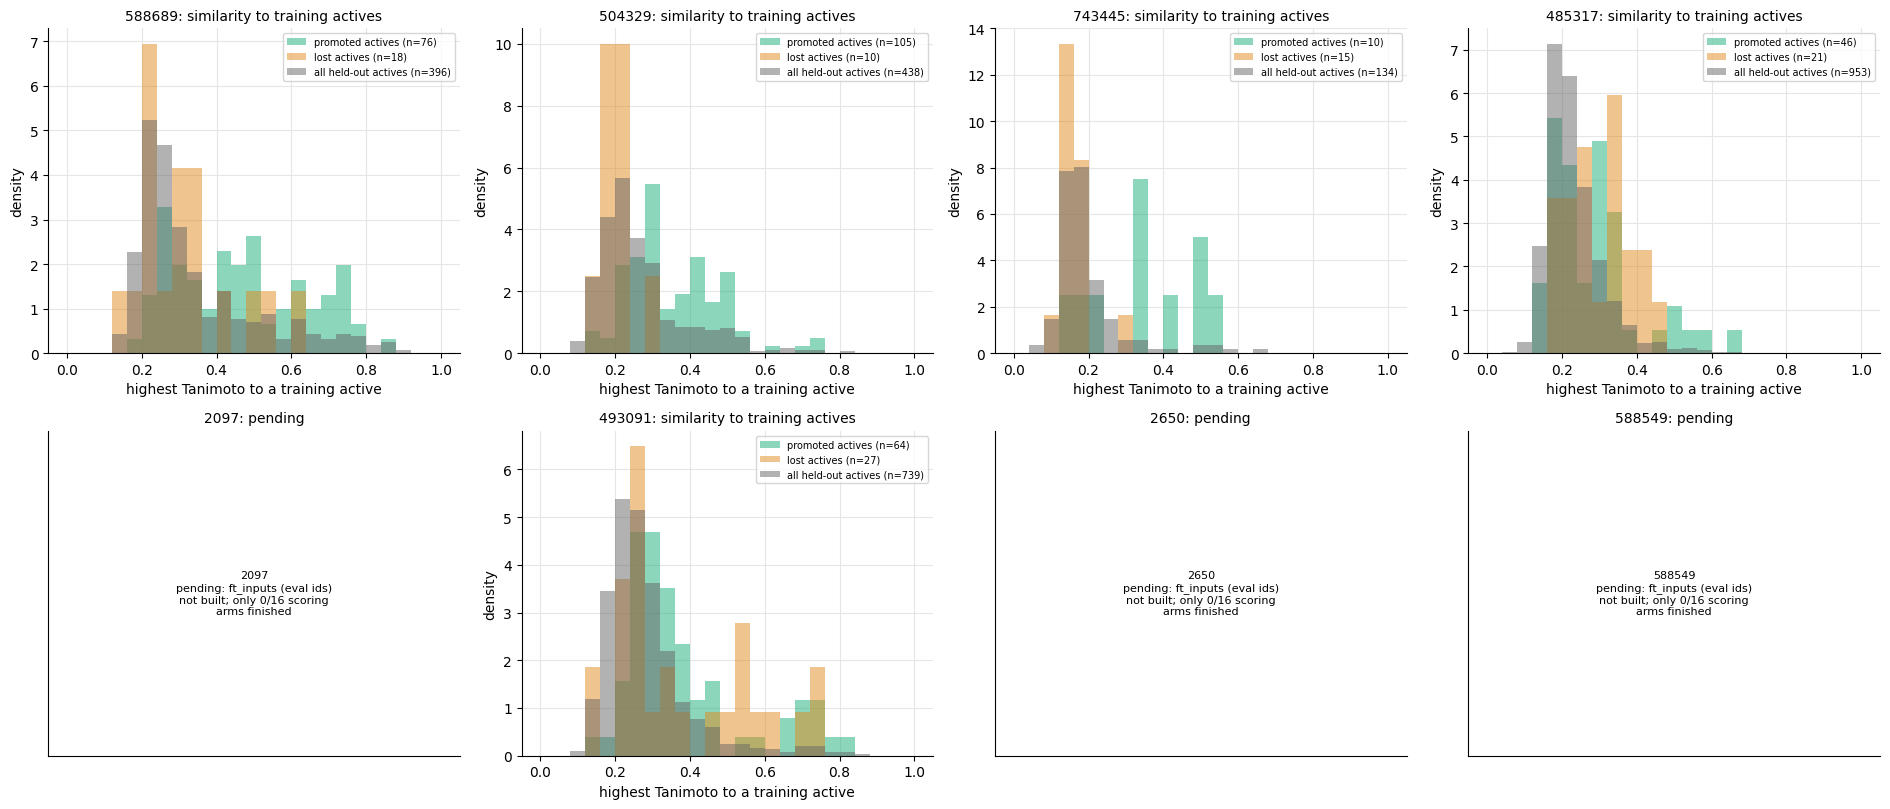

n       median  \
target comparison                                                              
588689 promoted actives vs lost actives                 76 / 18  0.47 / 0.31   
       promoted actives vs all held-out actives        76 / 396  0.47 / 0.28   
       new false positives vs random inactives (500)  276 / 500  0.26 / 0.22   
504329 promoted actives vs lost actives                105 / 10  0.32 / 0.20   
       promoted actives vs all held-out actives       105 / 438  0.32 / 0.23   
       new false positives vs random inactives (500)  271 / 500  0.24 / 0.20   
743445 promoted actives vs lost actives                 10 / 15  0.34 / 0.15   
       promoted actives vs all held-out actives        10 / 134  0.34 / 0.17   
       new false positives vs random inactives (500)  392 / 500  0.20 / 0.17   
485317 promoted actives vs lost actives                 46 / 21  0.26 / 0.29   
       promoted actives vs all held-out actives        46 / 953  0.26 / 0.21   
       new false positives vs random inactives (500)  332 / 500  0.24 / 0.19   
493091 promoted actives vs lost actives                 64 / 27  0.32 / 0.30   
       promoted actives vs all held-out actives        64 / 739  0.32 / 0.26   
       new false positives vs random inactives (500)  294 / 500  0.28 / 0.21   

                                                        MW_p  
target comparison                                             
588689 promoted actives vs lost actives               0.0010  
       promoted actives vs all held-out actives       0.0000  
       new false positives vs random inactives (500)  0.0000  
504329 promoted actives vs lost actives               0.0000  
       promoted actives vs all held-out actives       0.0000  
       new false positives vs random inactives (500)  0.0000  
743445 promoted actives vs lost actives               0.0017  
       promoted actives vs all held-out actives       0.0008  
       new false positives vs random inactives (500)  0.0000  
485317 promoted actives vs lost actives               0.2290  
       promoted actives vs all held-out actives       0.0024  
       new false positives vs random inactives (500)  0.0000  
493091 promoted actives vs lost actives               0.5174  
       promoted actives vs all held-out actives       0.0000  
       new false positives vs random inactives (500)  0.0000

15 Mann-Whitney tests; Bonferroni threshold for 0.05: 0.0033


In [13]:
rows = []
for t, r in RR.items():
    try:
        S, G = r["S"], r["G"]; tt = sim_table(t); tr = train_ids(t, 300)
        if tr is None: print(f"{SHORT[t]}: pending: no train_ids_top300.txt"); continue
        tra = [i for i in tr if bool(tt.target_active_v2.get(i, False))]; ref = [f for f in fps(tt["neut-smiles"].reindex(tra).values) if f is not None]
        grp = dict(G); grp["all held-out actives"] = S.label == 1; grp["random inactives (500)"] = S.index.isin(S[S.label == 0].sample(n=min(500, int((S.label == 0).sum())), random_state=0).index)
        SIM[t] = {}
        for g in ["promoted actives", "lost actives", "kept actives", "all held-out actives", "new false positives", "demoted false positives", "random inactives (500)"]:
            m = grp[g] if isinstance(grp[g], pd.Series) else pd.Series(grp[g], index=S.index); v = max_sim(S[m.values].smiles.values, ref); SIM[t][g] = v
            rows.append(dict(target=SHORT[t], group=g, n=len(v), median_maxTanimoto=np.nanmedian(v) if len(v) else np.nan, pct_ge_0_5=100 * np.nanmean(v >= 0.5) if len(v) else np.nan, pct_ge_0_6=100 * np.nanmean(v >= 0.6) if len(v) else np.nan))
        SIM[t]["n_train_actives"] = len(ref)
    except Exception as e:
        print(f"{SHORT[t]}: similarity failed ({type(e).__name__}: {e}); skipped")
TS = pd.DataFrame(rows)
if len(TS): display(TS.set_index(["target", "group"]).round(2))
for t in SIM: print(f"{SHORT[t]}: {SIM[t]['n_train_actives']} training actives used as reference")
fig, AX = grid(); b = np.linspace(0, 1, 26)
for t, ax in AX.items():
    if t not in SIM: placeholder(ax, t); ax.set_title(f"{SHORT[t]}: pending", fontsize=10); continue
    for g, c in [("promoted actives", "#1baf7a"), ("lost actives", "#e08a1e"), ("all held-out actives", GREY)]:
        v = SIM[t][g][~np.isnan(SIM[t][g])]
        if len(v): ax.hist(v, bins=b, density=True, alpha=0.5, color=c, label=f"{g} (n={len(v)})")
    ax.set_xlabel("highest Tanimoto to a training active"); ax.set_ylabel("density"); ax.set_title(f"{SHORT[t]}: similarity to training actives", fontsize=10); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
ST = []
for t in SIM:
    for a_, b_ in [("promoted actives", "lost actives"), ("promoted actives", "all held-out actives"), ("new false positives", "random inactives (500)")]:
        x, z = SIM[t][a_][~np.isnan(SIM[t][a_])], SIM[t][b_][~np.isnan(SIM[t][b_])]
        ST.append(dict(target=SHORT[t], comparison=f"{a_} vs {b_}", n=f"{len(x)} / {len(z)}", median=f"{np.median(x):.2f} / {np.median(z):.2f}" if len(x) and len(z) else "", MW_p=mannwhitneyu(x, z).pvalue if len(x) > 2 and len(z) > 2 else np.nan))
if ST: display(pd.DataFrame(ST).set_index(["target", "comparison"]).round(4)); print(f"{len(ST)} Mann-Whitney tests; Bonferroni threshold for 0.05: {0.05/len(ST):.4f}")

### The molecules: promoted and lost actives, with Tanimoto similarity to the nearest training active
For each filled target, up to 8 promoted and 8 lost actives (largest rank change first). Each active is drawn **next to the training active it most resembles**: the legend of the first molecule gives its compound id, its rank under No-FT then under head-FT, and the **ECFP4 Tanimoto** (2048 bits, radius 2) to the nearest of the 300-compound training set's actives; the legend of the second molecule marks the nearest training active. A scatter then plots that Tanimoto against the rank change for every promoted and lost active of the target.

588689: promoted actives (76 in total), each with its nearest training active


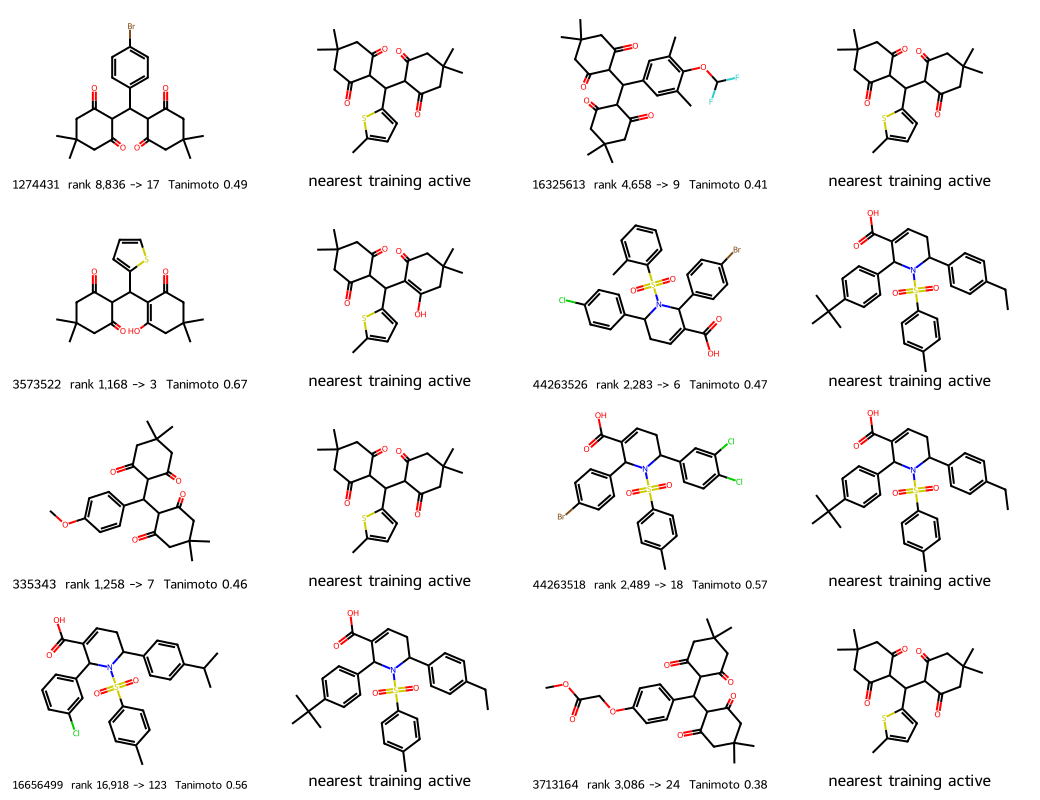

588689: lost actives (18 in total), each with its nearest training active


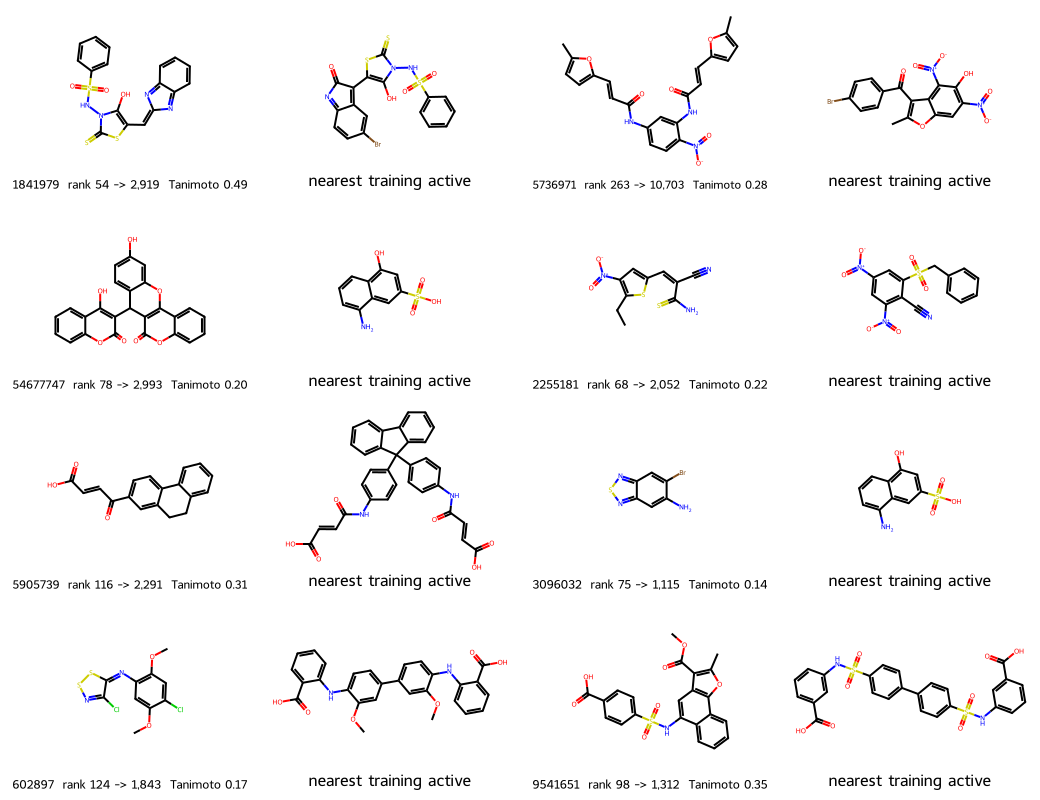

504329: promoted actives (105 in total), each with its nearest training active


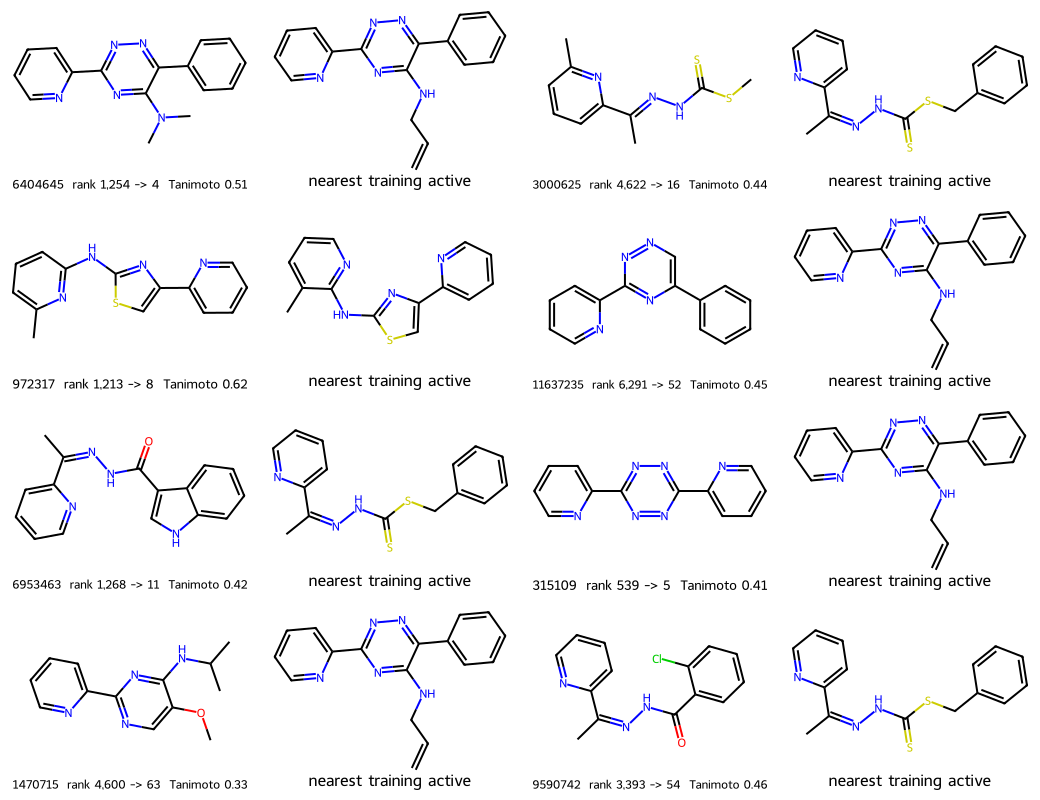

504329: lost actives (10 in total), each with its nearest training active


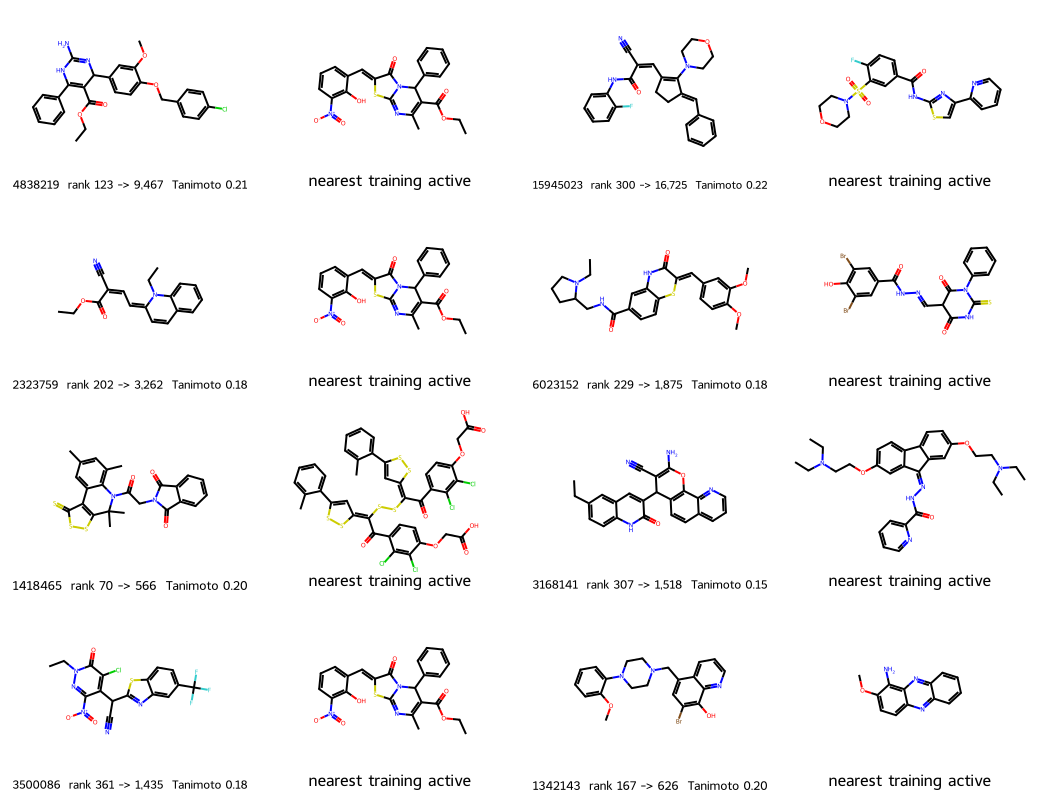

743445: promoted actives (10 in total), each with its nearest training active


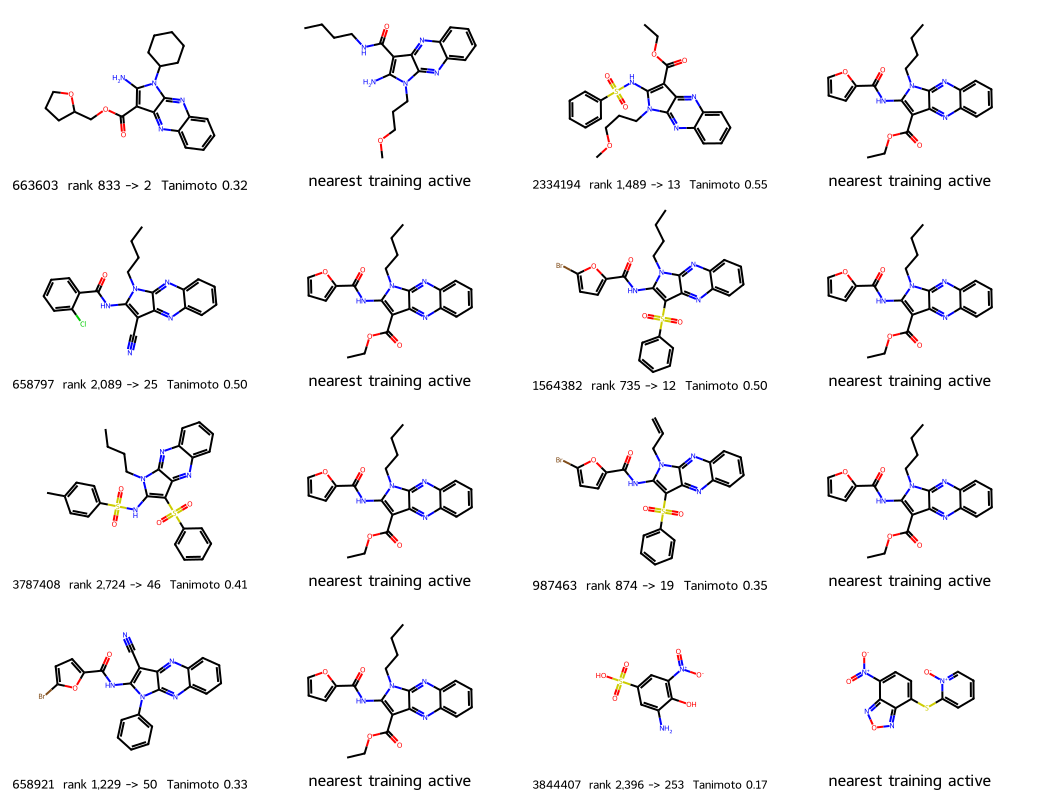

743445: lost actives (15 in total), each with its nearest training active


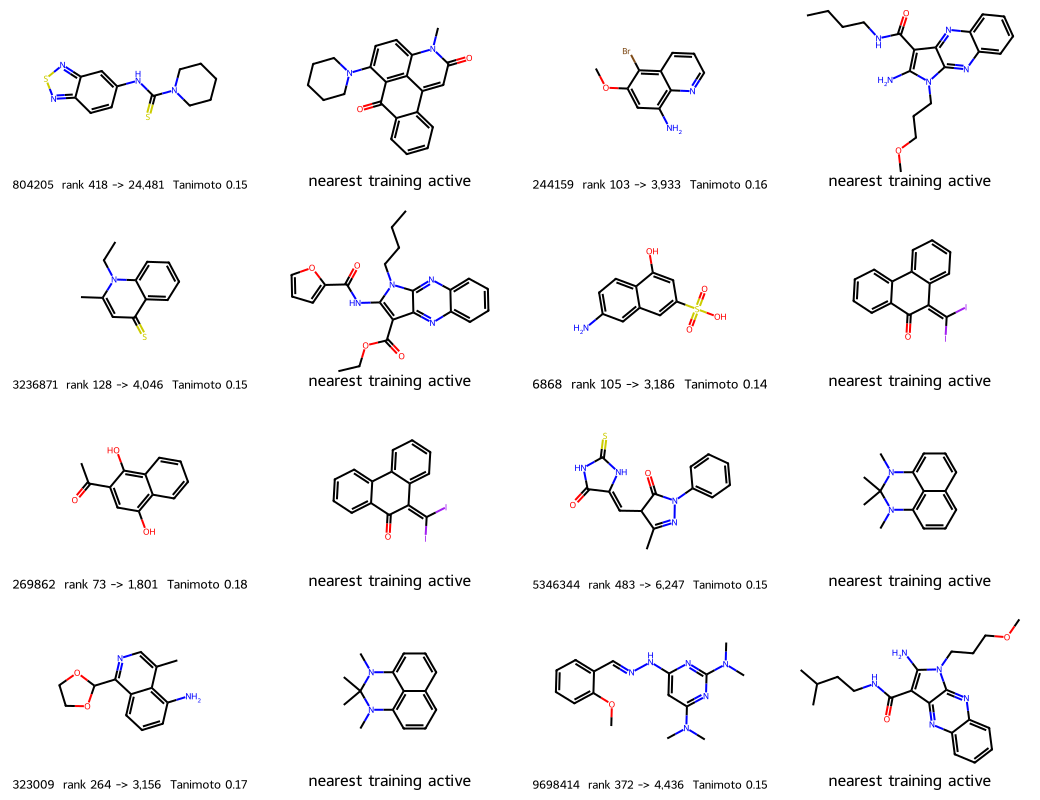

485317: promoted actives (46 in total), each with its nearest training active


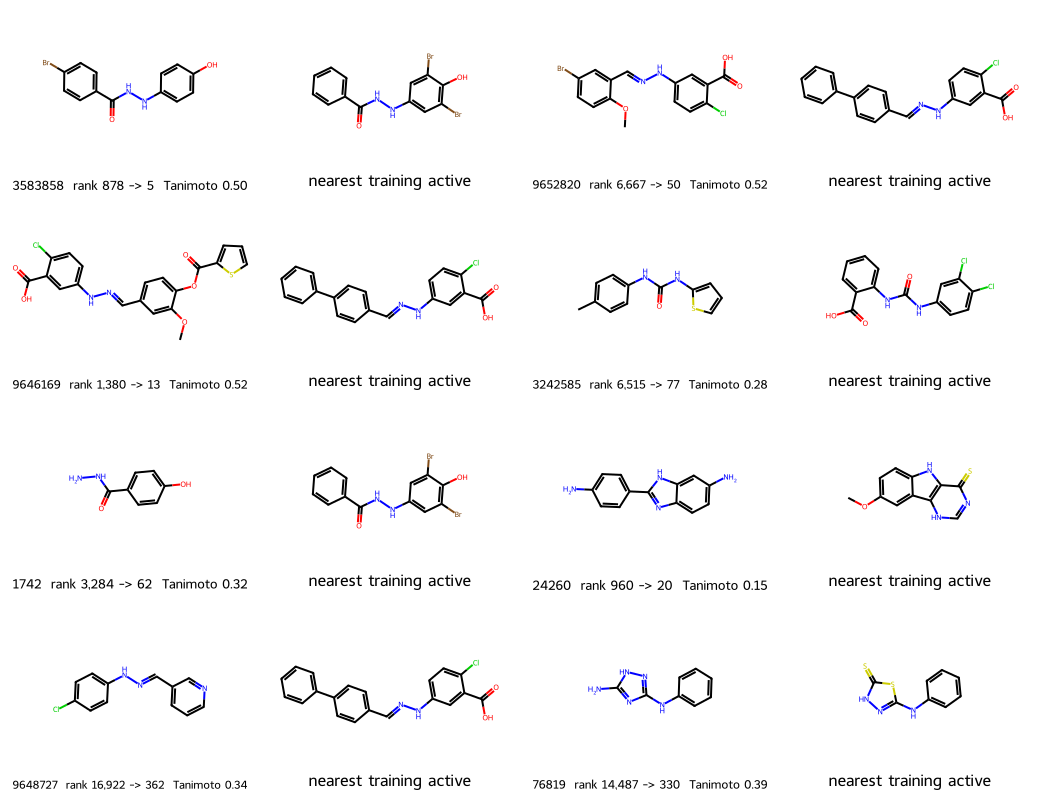

485317: lost actives (21 in total), each with its nearest training active


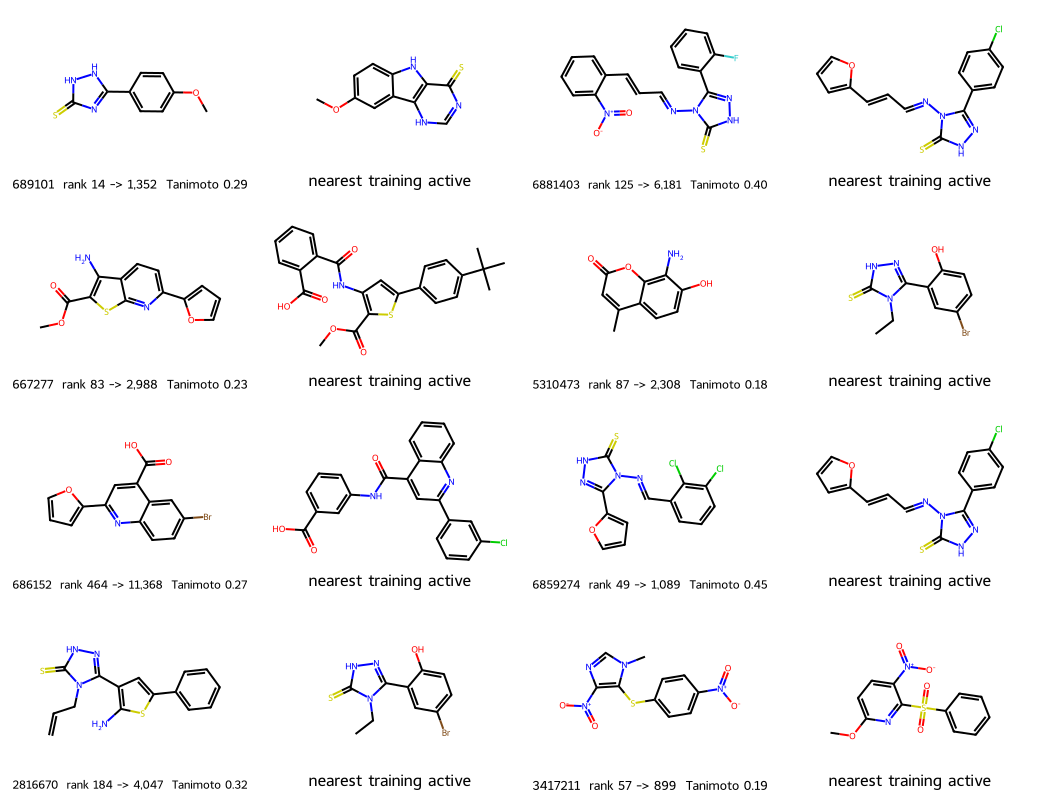

493091: promoted actives (64 in total), each with its nearest training active


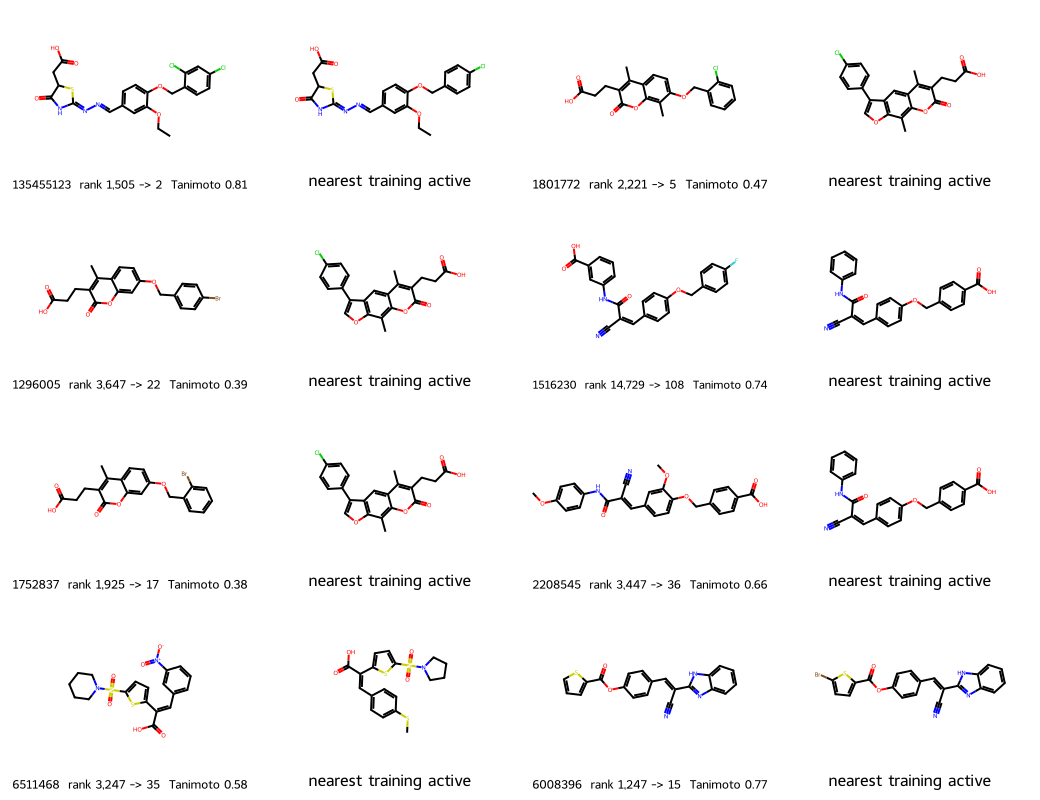

493091: lost actives (27 in total), each with its nearest training active


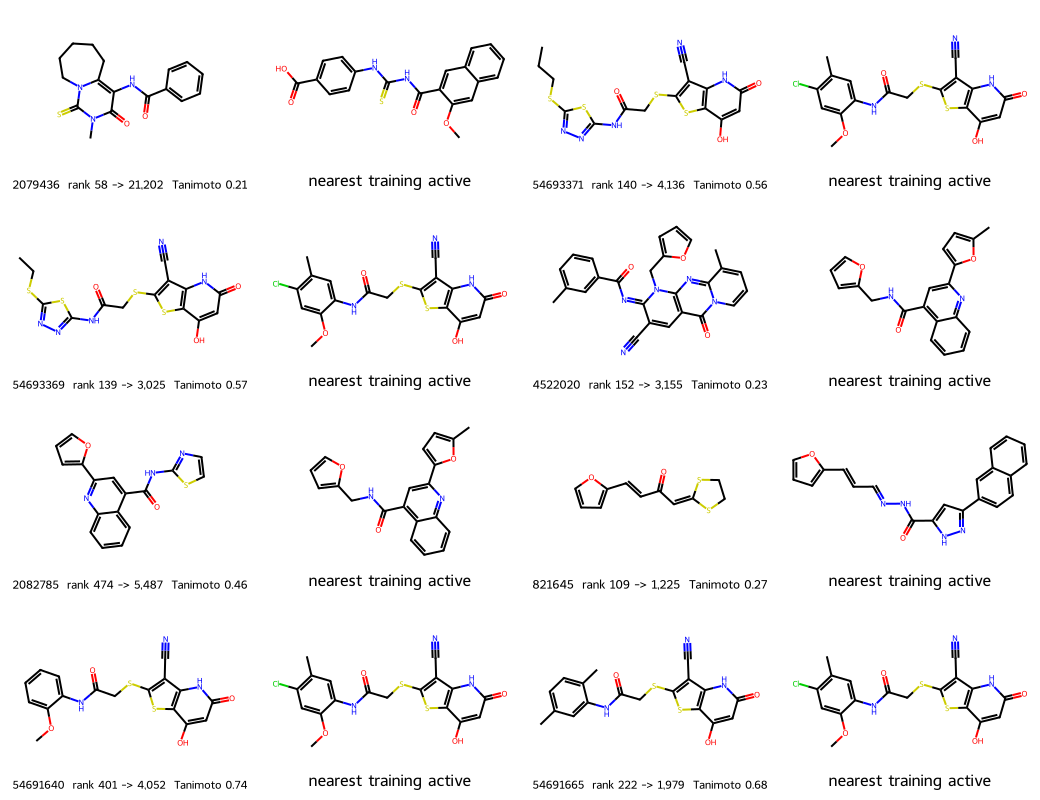

2097: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
2650: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished
588549: pending: ft_inputs (eval ids) not built; only 0/16 scoring arms finished


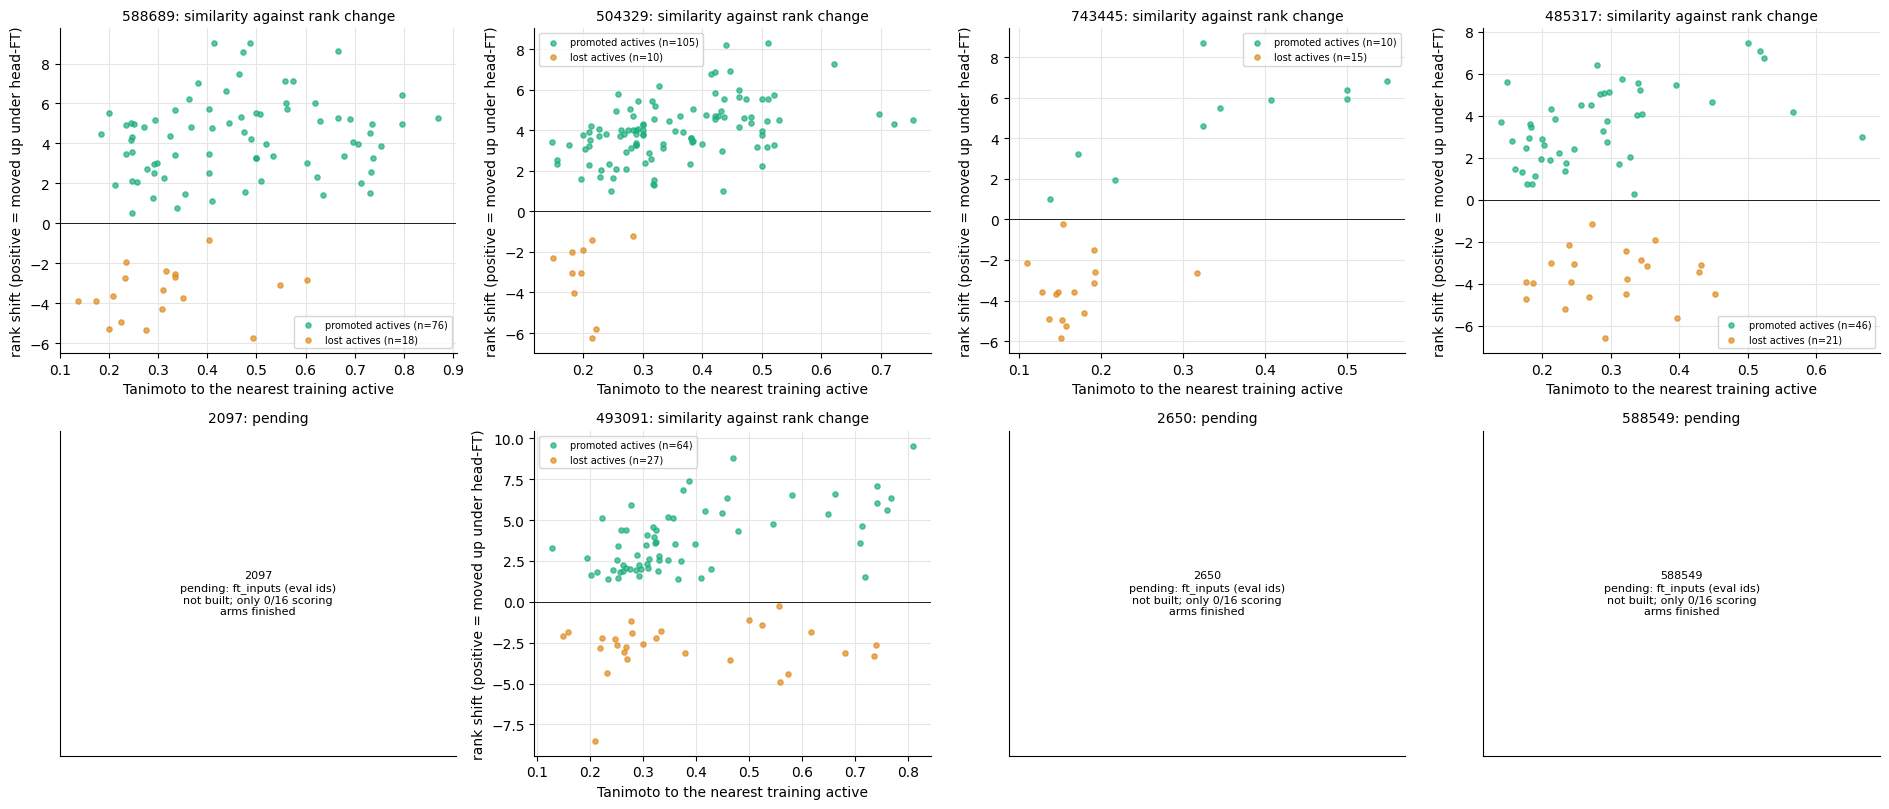

In [14]:
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw
def nearest_train(smiles, ref_fps):
    out = []
    for f in fps(smiles):
        if f is None: out.append((np.nan, -1)); continue
        sims = DataStructs.BulkTanimotoSimilarity(f, ref_fps); j = int(np.argmax(sims)); out.append((float(sims[j]), j))
    return out
REFS = {}
for t, r in RR.items():
    try:
        tt = sim_table(t); tr = train_ids(t, 300)
        if tr is None: print(f"{SHORT[t]}: pending: no train_ids_top300.txt"); continue
        tra = [i for i in tr if bool(tt.target_active_v2.get(i, False))]; smi = list(tt["neut-smiles"].reindex(tra).values)
        keep = [(s, f) for s, f in zip(smi, fps(smi)) if f is not None]; REFS[t] = ([k[0] for k in keep], [k[1] for k in keep])
    except Exception as e: print(f"{SHORT[t]}: could not build the training-active reference ({type(e).__name__}: {e})")
def draw_pairs(df, ref, n, title):
    d = df.head(n); nn = nearest_train(d.smiles.values, ref[1]); mols, leg = [], []
    for (_, r), (sim, j) in zip(d.iterrows(), nn):
        m = Chem.MolFromSmiles(r.smiles); k = Chem.MolFromSmiles(ref[0][j]) if j >= 0 else None
        if m is None or k is None: continue
        mols += [m, k]; leg += [f"{str(r.id).split('_')[-1]}  rank {int(r.rank_noft):,} -> {int(r.rank_ft):,}  Tanimoto {sim:.2f}", "nearest training active"]
    if not mols: print(title, ": nothing to draw"); return
    print(title); display(Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(260, 200), legends=leg))
SC = {}
for t, r in RR.items():
    if t not in REFS: continue
    S, G = r["S"], r["G"]; ref = REFS[t]
    draw_pairs(S[G["promoted actives"]].sort_values("rshift", ascending=False), ref, 8, f"{SHORT[t]}: promoted actives ({int(G['promoted actives'].sum())} in total), each with its nearest training active")
    draw_pairs(S[G["lost actives"]].sort_values("rshift"), ref, 8, f"{SHORT[t]}: lost actives ({int(G['lost actives'].sum())} in total), each with its nearest training active")
    SC[t] = {g: (max_sim(S[G[g]].smiles.values, ref[1]), S[G[g]].rshift.values) for g in ("promoted actives", "lost actives")}
for t in PEND: print(f"{SHORT[t]}: {PEND[t]}")
if SC:
    fig, AX = grid()
    for t, ax in AX.items():
        if t not in SC: placeholder(ax, t); ax.set_title(f"{SHORT[t]}: pending", fontsize=10); continue
        for g, c in (("promoted actives", "#1baf7a"), ("lost actives", "#e08a1e")):
            sim, sh = SC[t][g]; ax.scatter(sim, sh, s=14, color=c, alpha=0.7, label=f"{g} (n={len(sim)})")
        ax.axhline(0, color="black", lw=0.6); ax.set_xlabel("Tanimoto to the nearest training active"); ax.set_ylabel("rank shift (positive = moved up under head-FT)"); ax.set_title(f"{SHORT[t]}: similarity against rank change", fontsize=10); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

## 4. Per-target summary and cross-target panel

Average precision (AP) and EF1% are given for our runs next to the paper. Ours for head-FT is the mean +/- SD over the 5 seeds (AP) or the 5-seed ensemble (EF1%, top-1% counts). Targets are the unit for the cross-target claims; the sign test counts targets, not compounds.

In [15]:
from sklearn.metrics import average_precision_score as AP
rows = []
for t in TARGETS:
    pb, pf = paper_row(t), paper_row(t, 300)
    row = dict(target=SHORT[t], status="filled" if t in D else PEND[t], paper_AP_noft=pb.auprc if pb is not None else np.nan, paper_AP_ft300=pf.auprc if pf is not None else np.nan,
               paper_EF1_noft=pb.ef_1pct if pb is not None else np.nan, paper_EF1_ft300=pf.ef_1pct if pf is not None else np.nan)
    if t in D:
        d = D[t]; y = d["y"]; k = kof(0.01, d["N"]); rt = d["y"].mean(); aps = [AP(y, s) for s in d["per"]["FT N=300"]]; ef = lambda s: conf_k(s, y, k)["TP"] / k / rt
        row.update(n_eval=d["N"], n_active=d["P"], AP_noft=AP(y, d["ens"]["No-FT"]), AP_ft300=f"{np.mean(aps):.3f} +/- {np.std(aps, ddof=1):.3f}", AP_ratio=np.mean(aps) / AP(y, d["ens"]["No-FT"]),
                   EF1_noft=ef(d["ens"]["No-FT"]), EF1_ft300=ef(d["ens"]["FT N=300"]))
        if t in R2:
            r = R2[t]; m = r["matched"].set_index("level")
            row.update(TP1_noft=r["TP_a"], TP1_ft300=r["TP_b"], dTP1=r["dTP"], dTP1_CI=f"[{r['dTP_ci'][0]:+.0f}, {r['dTP_ci'][1]:+.0f}]", FP1_noft=r["FP_a"], FP1_ft300=r["FP_b"],
                       thr_verdict=verdict(r["thr_a"], r["thr_b"]), dFP_at_sens50=m.loc["sensitivity 50%", "dFP"])
        if t in RR: row.update(promoted=int(RR[t]["G"]["promoted actives"].sum()), lost=int(RR[t]["G"]["lost actives"].sum()))
    rows.append(row)
T4 = pd.DataFrame(rows).set_index("target"); pd.set_option("display.width", 250, "display.max_columns", 40); display(T4.round(3))

,status,paper_AP_noft,paper_AP_ft300,paper_EF1_noft,paper_EF1_ft300,n_eval,n_active,AP_noft,AP_ft300,AP_ratio,EF1_noft,EF1_ft300,TP1_noft,TP1_ft300,dTP1,dTP1_CI,FP1_noft,FP1_ft300,thr_verdict,dFP_at_sens50,promoted,lost
target,,,,,,,,,,,,,,,,,,,,,,
588689,filled,0.096,0.237,18.176,31.809,49685.0,396.0,0.097,0.207 +/- 0.015,2.124,16.914,31.556,67.0,125.0,58.0,"[+40, +76]",430.0,372.0,trade-off: fewer false positives but more miss...,-895.0,76.0,18.0
504329,filled,0.047,0.222,7.988,31.039,49673.0,438.0,0.051,0.174 +/- 0.021,3.424,9.812,31.490,43.0,138.0,95.0,"[+78, +115]",454.0,359.0,trade-off: fewer false positives but more miss...,-1682.0,105.0,10.0
743445,filled,0.022,0.048,15.670,17.162,49695.0,134.0,0.022,0.043 +/- 0.002,1.919,16.416,12.685,22.0,17.0,-5.0,"[-16, +5]",475.0,480.0,trade-off: fewer false positives but more miss...,3468.0,10.0,15.0
485317,filled,0.036,0.060,3.461,7.132,49676.0,953.0,0.039,0.054 +/- 0.002,1.395,4.090,6.712,39.0,64.0,25.0,"[+8, +38]",458.0,433.0,trade-off: fewer false positives but more miss...,-3417.0,46.0,21.0
2097,pending: ft_inputs (eval ids) not built; only ...,0.081,0.286,18.078,32.781,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
493091,filled,0.059,0.095,7.170,13.934,49685.0,739.0,0.059,0.095 +/- 0.008,1.625,7.711,12.716,57.0,94.0,37.0,"[+20, +55]",440.0,403.0,trade-off: fewer false positives but more miss...,-863.0,64.0,27.0
2650,pending: ft_inputs (eval ids) not built; only ...,0.071,0.117,13.833,19.366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
588549,pending: ft_inputs (eval ids) not built; only ...,0.006,0.007,2.666,3.332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


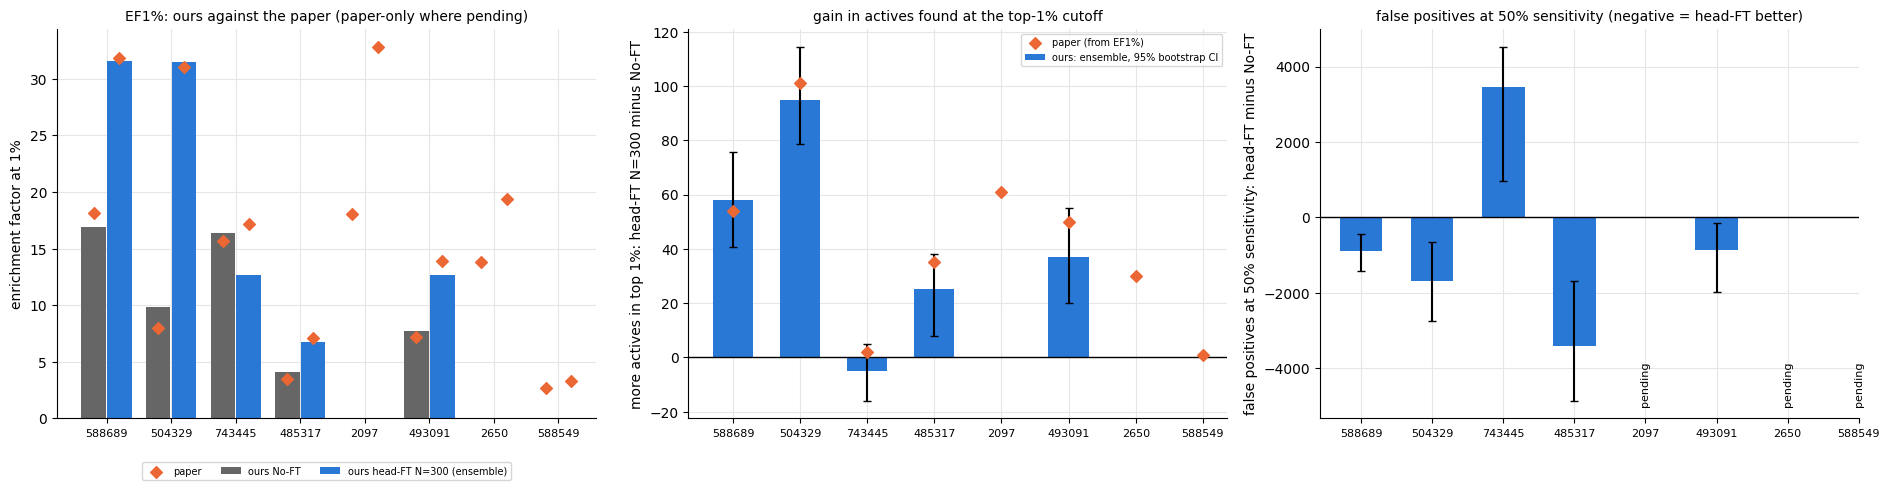

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(19, 5)); X = np.arange(len(TARGETS)); lab = [SHORT[t] for t in TARGETS]
ax = axs[0]   # EF1% ours vs paper
for i, t in enumerate(TARGETS):
    if t in D:
        ax.bar(i - 0.2, T4.loc[SHORT[t], "EF1_noft"], 0.38, color=GREY, label="ours No-FT" if i == 0 else None); ax.bar(i + 0.2, T4.loc[SHORT[t], "EF1_ft300"], 0.38, color=OUR, label="ours head-FT N=300 (ensemble)" if i == 0 else None)
    ax.scatter(i - 0.2, T4.loc[SHORT[t], "paper_EF1_noft"], marker="D", color=THEIR, zorder=4, s=36, label="paper" if i == 0 else None); ax.scatter(i + 0.2, T4.loc[SHORT[t], "paper_EF1_ft300"], marker="D", color=THEIR, zorder=4, s=36)
ax.set_xticks(X); ax.set_xticklabels(lab, fontsize=8); ax.set_ylabel("enrichment factor at 1%"); ax.set_title("EF1%: ours against the paper (paper-only where pending)", fontsize=10); ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
ax = axs[1]   # delta TP at top 1%
for i, t in enumerate(TARGETS):
    if t in R2:
        r = R2[t]; ax.bar(i, r["dTP"], 0.6, color=OUR, yerr=[[r["dTP"] - r["dTP_ci"][0]], [r["dTP_ci"][1] - r["dTP"]]], capsize=3, ecolor=BLK, label="ours: ensemble, 95% bootstrap CI" if i == 0 or (i > 0 and not any(x in R2 for x in TARGETS[:i])) else None)
    ax.scatter(i, paper_tp(t, 300) - paper_tp(t), marker="D", color=THEIR, zorder=4, s=36, label="paper (from EF1%)" if i == 0 else None)
ax.axhline(0, color=BLK, lw=1); ax.set_xticks(X); ax.set_xticklabels(lab, fontsize=8); ax.set_ylabel("more actives in top 1%: head-FT N=300 minus No-FT"); ax.set_title("gain in actives found at the top-1% cutoff", fontsize=10); ax.legend(fontsize=7)
ax = axs[2]   # delta FP at matched sensitivity 50%
for i, t in enumerate(TARGETS):
    if t in R2:
        m = R2[t]["matched"].set_index("level").loc["sensitivity 50%"]; c = m.dFP_ci; ax.bar(i, m.dFP, 0.6, color=OUR, yerr=[[m.dFP - c[0]], [c[1] - m.dFP]], capsize=3, ecolor=BLK)
    else: ax.text(i, 0.03, "pending", rotation=90, ha="center", va="bottom", fontsize=8, transform=ax.get_xaxis_transform())
ax.axhline(0, color=BLK, lw=1); ax.set_xticks(X); ax.set_xticklabels(lab, fontsize=8); ax.set_ylabel("false positives at 50% sensitivity: head-FT minus No-FT"); ax.set_title("false positives at 50% sensitivity (negative = head-FT better)", fontsize=10)
plt.tight_layout(); plt.show()

In [17]:
def sign(vals, name):
    vals = [v for v in vals if v != 0]; n = len(vals); k = sum(v > 0 for v in vals)
    if n == 0: return f"{name}: no filled target, no test possible.", None
    p = stats.binomtest(k, n, 0.5).pvalue
    return f"{name}: n targets = {n}, k = {k} in the stated direction; exact two-sided sign test p = {p:.3g} (smallest attainable p with n = {n} is {2*0.5**n:.3g}).", p
tests = [sign([R2[t]["dTP"] for t in R2], "head-FT finds more top-1% actives than No-FT"),
         sign([-R2[t]["matched"].set_index("level").loc["sensitivity 50%", "dFP"] for t in R2], "head-FT needs fewer false positives than No-FT to reach 50% sensitivity"),
         sign([int(RR[t]["G"]["promoted actives"].sum()) - int(RR[t]["G"]["lost actives"].sum()) for t in RR], "head-FT promotes more actives into the top 1% than it loses")]
for s, p in tests: print(s)
print(f"{len(tests)} sign tests were run; Bonferroni threshold for 0.05 is {0.05/len(tests):.4f}. A sign test ignores effect size and with few targets has little power; "
      f"in the paper's own table, head-FT N=300 beats No-FT in EF1% on {int(sum(paper_row(t, 300).ef_1pct > paper_row(t).ef_1pct for t in TARGETS))} of {len(TARGETS)} targets (fixed paper value).")

head-FT finds more top-1% actives than No-FT: n targets = 5, k = 4 in the stated direction; exact two-sided sign test p = 0.375 (smallest attainable p with n = 5 is 0.0625).
head-FT needs fewer false positives than No-FT to reach 50% sensitivity: n targets = 5, k = 4 in the stated direction; exact two-sided sign test p = 0.375 (smallest attainable p with n = 5 is 0.0625).
head-FT promotes more actives into the top 1% than it loses: n targets = 5, k = 4 in the stated direction; exact two-sided sign test p = 0.375 (smallest attainable p with n = 5 is 0.0625).
3 sign tests were run; Bonferroni threshold for 0.05 is 0.0167. A sign test ignores effect size and with few targets has little power; in the paper's own table, head-FT N=300 beats No-FT in EF1% on 8 of 8 targets (fixed paper value).


## Conclusions
Every number below is computed from the data above; nothing is stated for targets that are pending.

In [18]:
L = []
L.append(f"Targets filled: {len(D)} of {len(TARGETS)} ({', '.join(SHORT[t] for t in D) or 'none'}). Pending: {', '.join(SHORT[t] + ' (' + PEND[t].replace('pending: ', '') + ')' for t in PEND) or 'none'}.")
for t, r in R2.items():
    ta, tb = r["thr_a"], r["thr_b"]; m = r["matched"].set_index("level"); d = D[t]
    L.append(f"\nTarget {SHORT[t]} ({d['N']:,} held-out compounds, {d['P']} active, training compounds excluded).")
    L.append(f"  Matched top 1% (k = {r['k']}): head-FT N=300 ensemble finds {r['TP_b']} actives against {r['TP_a']} for No-FT (difference {r['dTP']:+d}, 95% bootstrap CI [{r['dTP_ci'][0]:+.0f}, {r['dTP_ci'][1]:+.0f}]; the 5 single seeds find {min(r['seed_TP'])} to {max(r['seed_TP'])}), "
             f"false positives {r['FP_b']} against {r['FP_a']}, missed actives {d['P']-r['TP_b']} against {d['P']-r['TP_a']}. Paper (EF1% converted): {paper_tp(t, 300):.0f} against {paper_tp(t):.0f}.")
    L.append(f"  Default p > 0.5: No-FT flags {ta['flagged']} (finds {ta['TP']}, FP {ta['FP']}, misses {ta['FN']}); head-FT ensemble flags {tb['flagged']} (finds {tb['TP']}, FP {tb['FP']}, misses {tb['FN']}). Verdict: {verdict(ta, tb)}.")
    x = m.loc["sensitivity 50%"]; L.append(f"  At 50% sensitivity No-FT accepts {x.FP_noft} false positives and head-FT {x.FP_ft} (specificity {100*x.spec_noft:.2f}% against {100*x.spec_ft:.2f}%; difference CI [{x.dFP_ci[0]:+.0f}, {x.dFP_ci[1]:+.0f}]).")
    if t in RR:
        g = RR[t]["G"]; L.append(f"  Re-ranking at the top 1%: {int(g['promoted actives'].sum())} actives promoted, {int(g['lost actives'].sum())} lost, {int(g['kept actives'].sum())} kept; {int(g['demoted false positives'].sum())} false positives removed, {int(g['new false positives'].sum())} created.")
    if t in SIM:
        s_ = lambda g: np.nanmedian(SIM[t][g]) if len(SIM[t][g]) else np.nan
        L.append(f"  Similarity to the {SIM[t]['n_train_actives']} training actives (median highest Tanimoto): promoted actives {s_('promoted actives'):.2f}, lost {s_('lost actives'):.2f}, all held-out actives {s_('all held-out actives'):.2f}.")
L.append("")
for s, p in tests: L.append(s)
L.append("Limits: intervals reflect the evaluation-set sample and not the choice of training compounds (the seed range is shown separately); the paper reports one value per target and budget; "
         "the evaluation set is disjoint from the 300 training compounds but not from their chemical families; per-target intervals are not corrected for multiplicity.")
print("\n".join(L))

Targets filled: 5 of 8 (588689, 504329, 743445, 485317, 493091). Pending: 2097 (ft_inputs (eval ids) not built; only 0/16 scoring arms finished), 2650 (ft_inputs (eval ids) not built; only 0/16 scoring arms finished), 588549 (ft_inputs (eval ids) not built; only 0/16 scoring arms finished).

Target 588689 (49,685 held-out compounds, 396 active, training compounds excluded).
  Matched top 1% (k = 497): head-FT N=300 ensemble finds 125 actives against 67 for No-FT (difference +58, 95% bootstrap CI [+40, +76]; the 5 single seeds find 116 to 131), false positives 372 against 430, missed actives 271 against 329. Paper (EF1% converted): 126 against 72.
  Default p > 0.5: No-FT flags 2062 (finds 190, FP 1872, misses 206); head-FT ensemble flags 200 (finds 75, FP 125, misses 321). Verdict: trade-off: fewer false positives but more missed actives.
  At 50% sensitivity No-FT accepts 2144 false positives and head-FT 1249 (specificity 95.65% against 97.47%; difference CI [-1411, -449]).
  Re-ranki